In [ ]:
!pip install xgboost lightgbm catboost shap --quiet
print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
✅ All libraries installed successfully!


In [ ]:
# ── Standard Libraries ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Style settings
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['axes.edgecolor']   = '#444'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#333'
plt.rcParams['font.family']      = 'DejaVu Sans'
PALETTE = sns.color_palette("husl", 22)

In [ ]:
# ── Machine Learning ───────────────────────────────────────────────────────
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing      import LabelEncoder, StandardScaler
from sklearn.ensemble           import RandomForestClassifier, StackingClassifier
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.naive_bayes        import GaussianNB
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (accuracy_score, classification_report,
                                        confusion_matrix, ConfusionMatrixDisplay)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
# ── SHAP ───────────────────────────────────────────────────────────────────
import shap

print("✅ All imports successful!")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")

✅ All imports successful!
   NumPy   : 2.0.2
   Pandas  : 2.2.2


In [ ]:
from google.colab import files
print("Please upload Crop_recommendation.csv ...")
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

print(f"\n/content/Crop_recommendation.csv")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\nFirst 5 rows:")
df.head()

Please upload Crop_recommendation.csv ...


Saving Crop_recommendation.csv to Crop_recommendation (1).csv

/content/Crop_recommendation.csv
   Rows    : 2200
   Columns : 8

First 5 rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
# ── Basic Info ────────────────────────────────────────────────────────────
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"Shape          : {df.shape}")
print(f"Features       : {df.columns[:-1].tolist()}")
print(f"Target         : label")
print(f"Unique Crops   : {df['label'].nunique()}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print()

print("CROP NAMES:")
print(sorted(df['label'].unique()))
print()

print("STATISTICAL SUMMARY:")
df.describe().round(2)

  DATASET OVERVIEW
Shape          : (2200, 8)
Features       : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Target         : label
Unique Crops   : 22
Missing Values : 0
Duplicates     : 0

CROP NAMES:
['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']

STATISTICAL SUMMARY:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


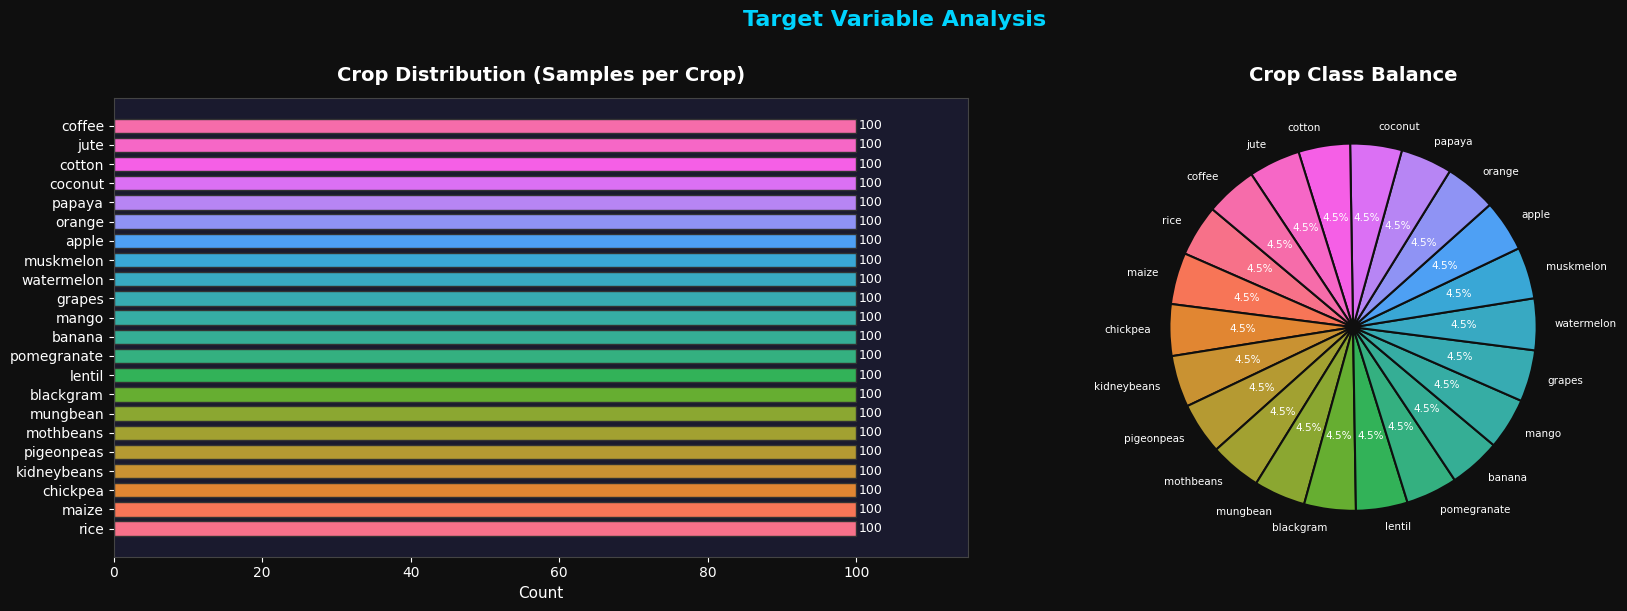

✅ Dataset is perfectly balanced — 100 samples per crop


In [ ]:
# ── Crop Distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f0f')

# Bar Chart
crop_counts = df['label'].value_counts().sort_values(ascending=True)
colors = sns.color_palette("husl", len(crop_counts))
axes[0].barh(crop_counts.index, crop_counts.values, color=colors, edgecolor='#333', height=0.75)
axes[0].set_title('Crop Distribution (Samples per Crop)', fontsize=14, fontweight='bold', color='white', pad=12)
axes[0].set_xlabel('Count', fontsize=11)
for i, v in enumerate(crop_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', color='white', fontsize=9)
axes[0].set_xlim(0, 115)

# Pie Chart
axes[1].pie(
    crop_counts.values,
    labels=crop_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'color': 'white', 'fontsize': 7.5},
    wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 1.5}
)
axes[1].set_title('Crop Class Balance', fontsize=14, fontweight='bold', color='white', pad=12)

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', color='#00d4ff', y=1.01)
plt.tight_layout()
plt.show()
print("✅ Dataset is perfectly balanced — 100 samples per crop")

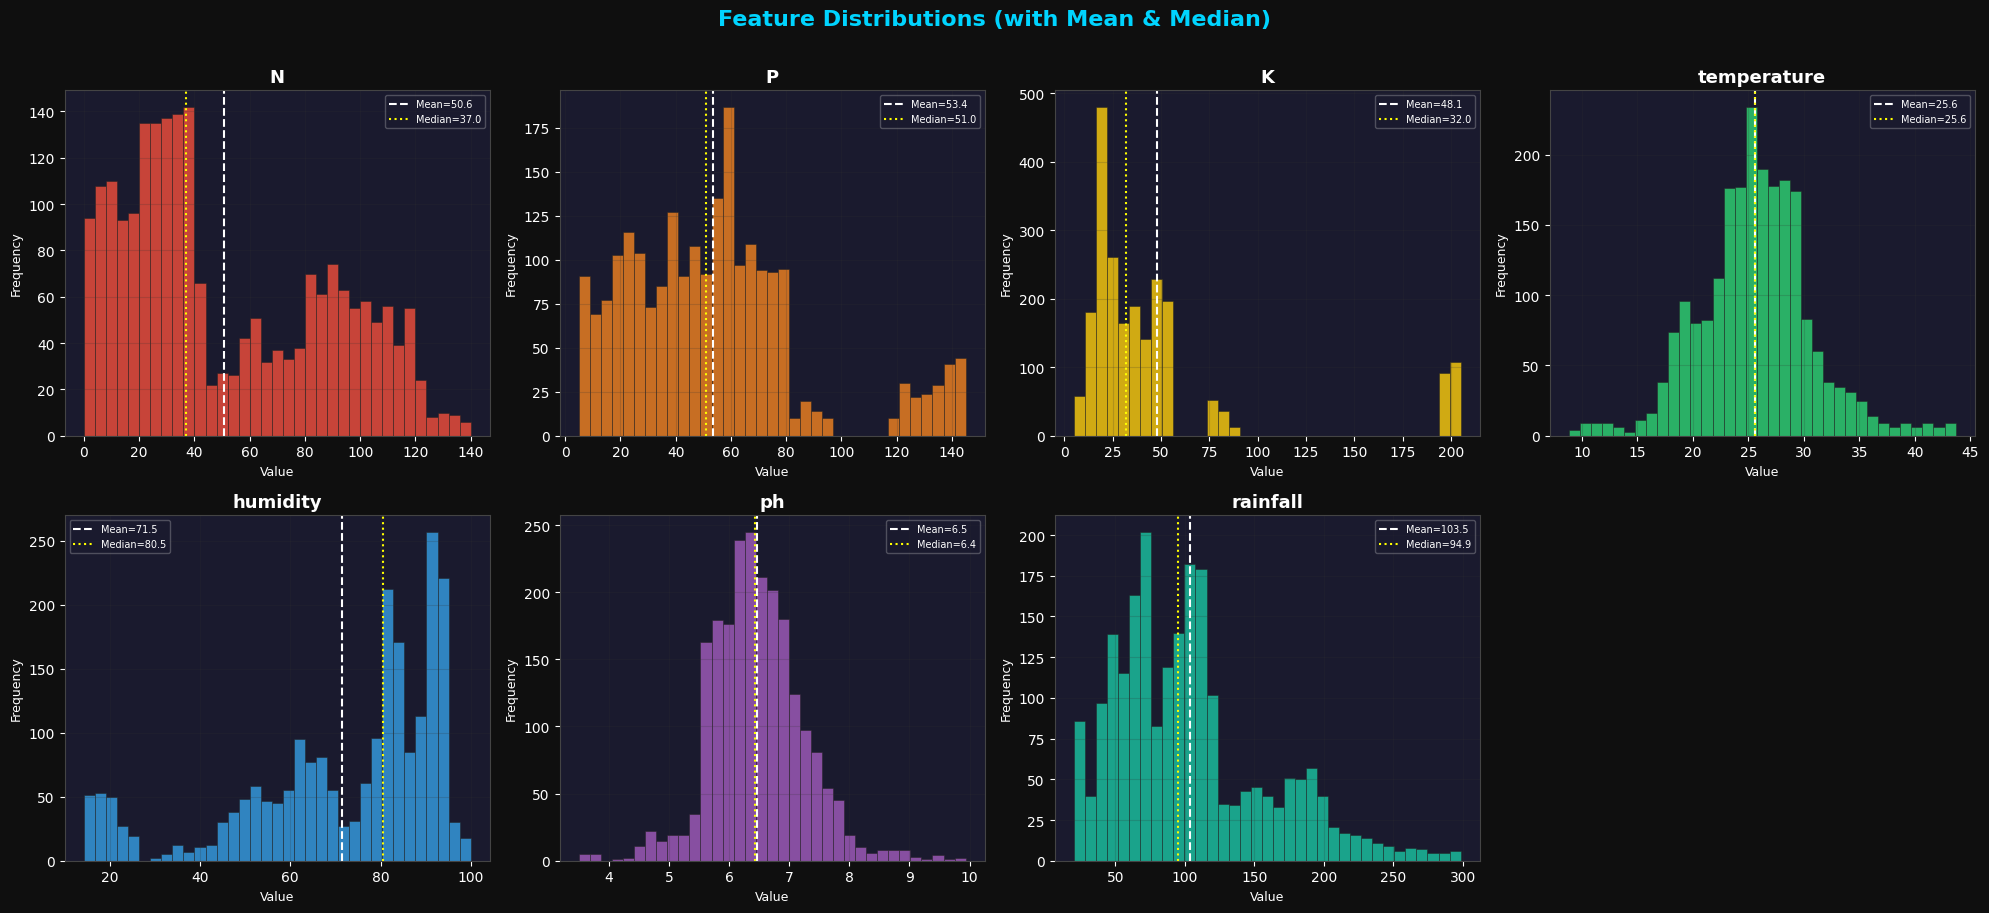

In [ ]:
# ── Feature Distributions ──────────────────────────────────────────────────
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

colors_grad = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6','#1abc9c']

for i, feat in enumerate(features):
    ax = axes[i]
    ax.hist(df[feat], bins=35, color=colors_grad[i], alpha=0.85, edgecolor='#222', linewidth=0.4)
    ax.axvline(df[feat].mean(),   color='white', linewidth=1.5, linestyle='--', label=f'Mean={df[feat].mean():.1f}')
    ax.axvline(df[feat].median(), color='yellow', linewidth=1.5, linestyle=':',  label=f'Median={df[feat].median():.1f}')
    ax.set_title(feat, fontsize=13, fontweight='bold', color='white')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=7, framealpha=0.3)
    ax.grid(True, alpha=0.2)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions (with Mean & Median)', fontsize=16,
             fontweight='bold', color='#00d4ff', y=1.01)
plt.tight_layout()
plt.show()

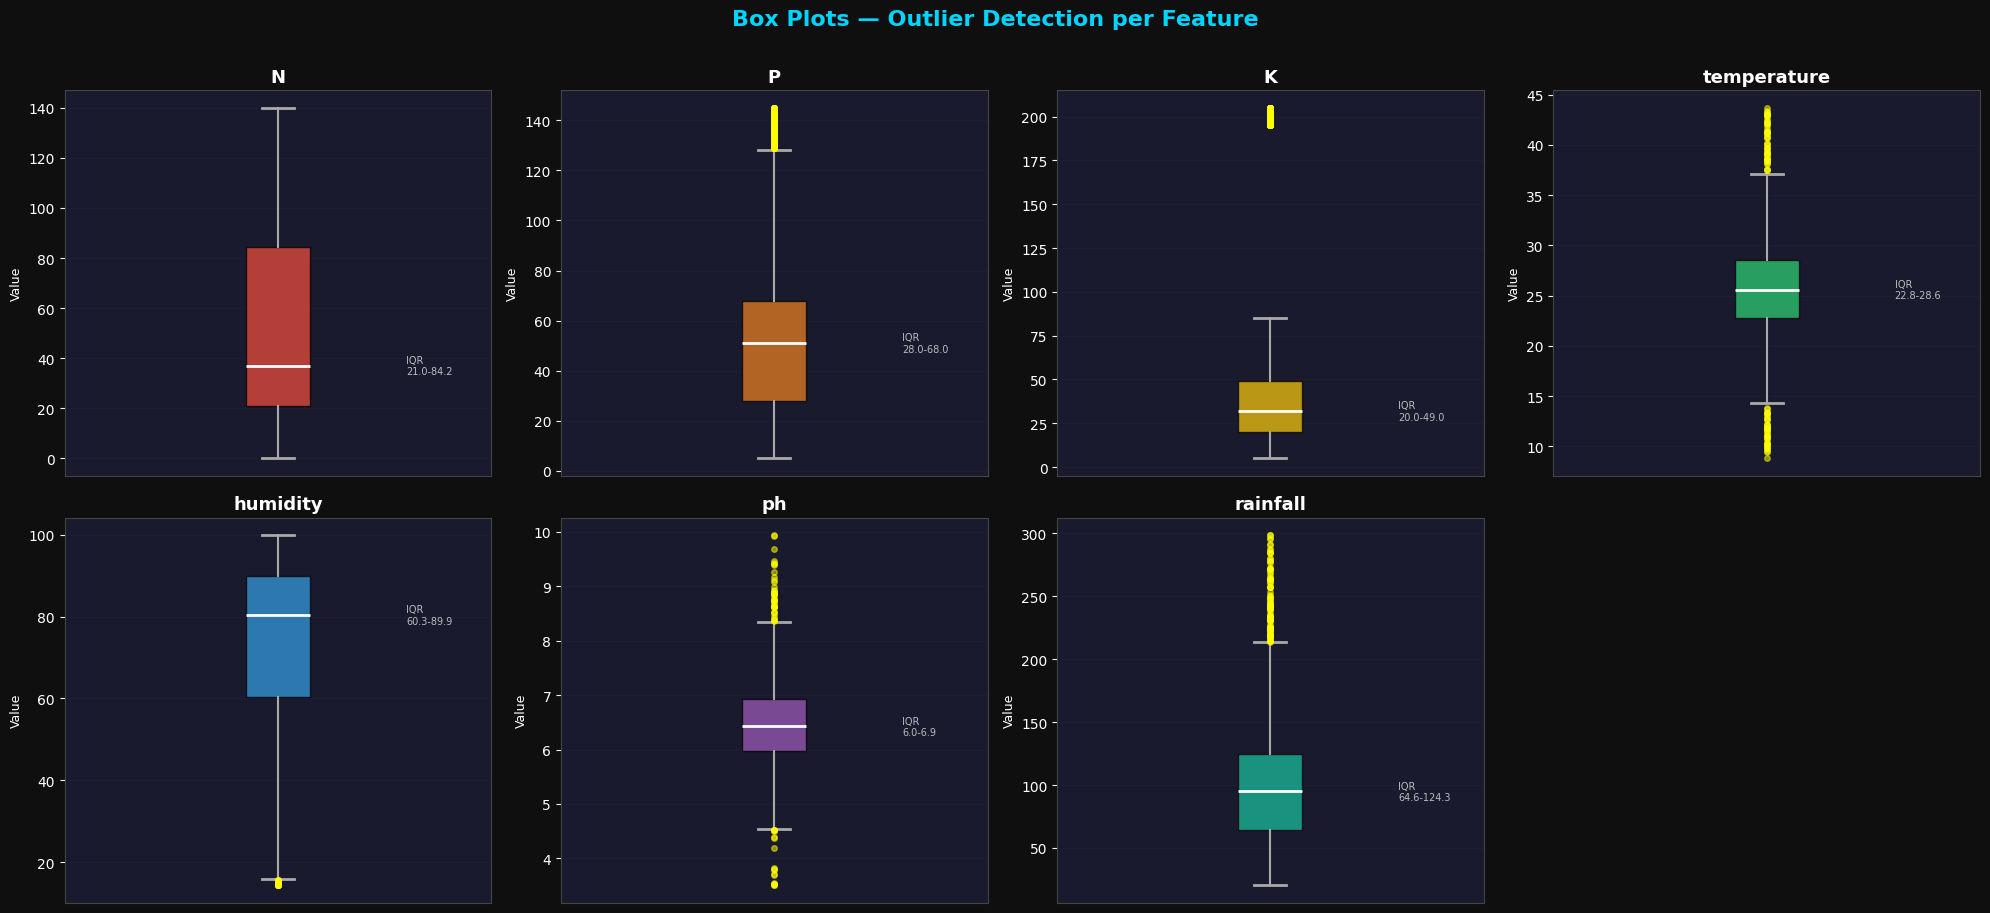

In [ ]:
# ── Box Plots — Outlier Detection ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

box_colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6','#1abc9c']

for i, feat in enumerate(features):
    ax = axes[i]
    bp = ax.boxplot(df[feat], patch_artist=True, vert=True,
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='yellow',
                                    markeredgecolor='yellow', markersize=4, alpha=0.5),
                    boxprops=dict(facecolor=box_colors[i], alpha=0.75),
                    whiskerprops=dict(color='#aaa', linewidth=1.5),
                    capprops=dict(color='#aaa', linewidth=2))
    ax.set_title(feat, fontsize=13, fontweight='bold', color='white')
    ax.set_ylabel('Value', fontsize=9)
    ax.set_xticks([])
    ax.grid(True, alpha=0.2, axis='y')

    # Show IQR stats
    q1, q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    ax.text(1.3, df[feat].median(), f'IQR\n{q1:.1f}-{q3:.1f}',
            va='center', ha='left', color='white', fontsize=7, alpha=0.7)

axes[-1].set_visible(False)
plt.suptitle('Box Plots — Outlier Detection per Feature', fontsize=16,
             fontweight='bold', color='#00d4ff', y=1.01)
plt.tight_layout()
plt.show()

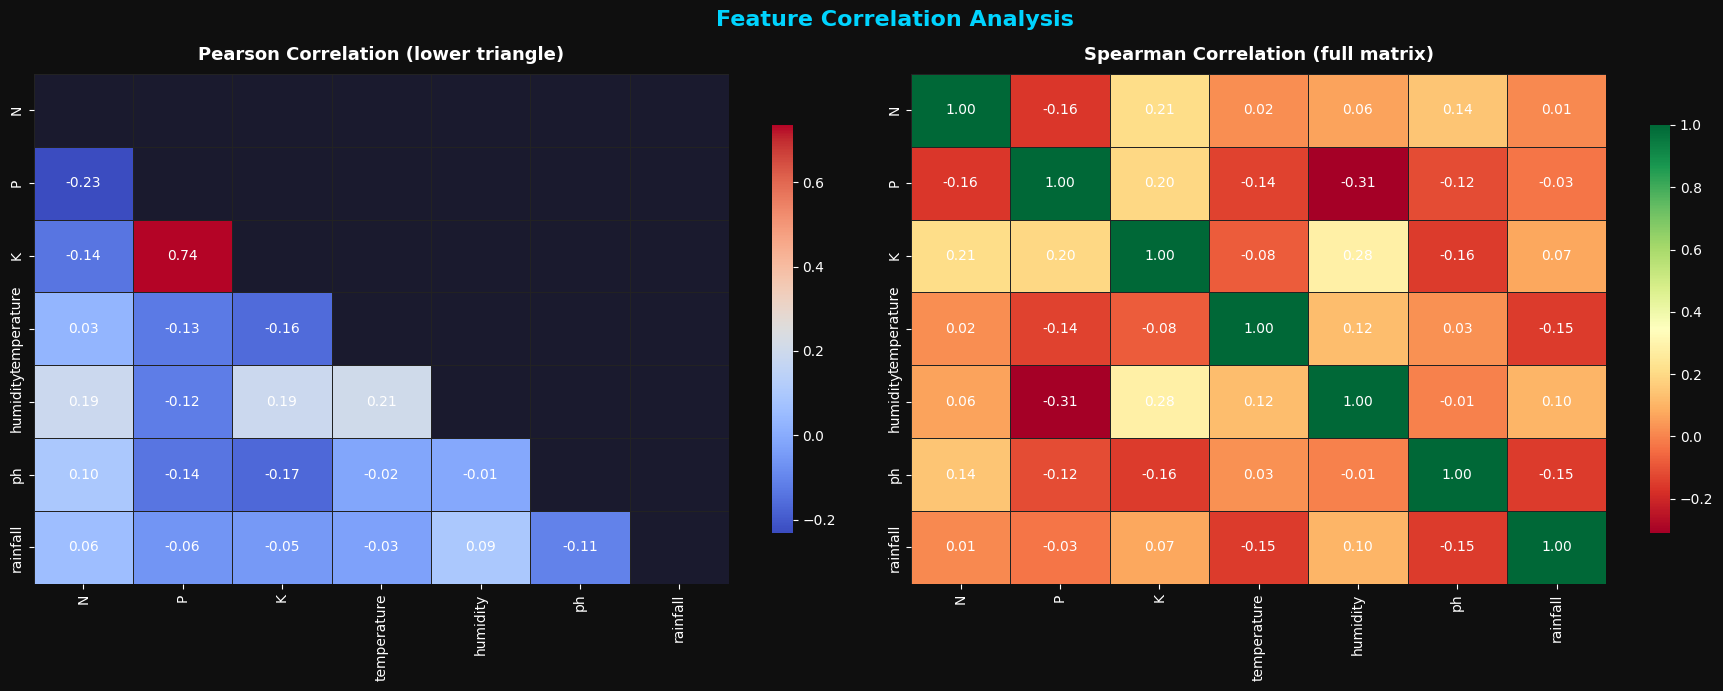

In [ ]:
# ── Correlation Heatmap ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f0f')

# Pearson Correlation
corr = df[features].corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, linecolor='#222',
            annot_kws={'size': 10, 'color': 'white'},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation (lower triangle)', fontsize=13,
                   fontweight='bold', color='white', pad=10)
axes[0].tick_params(colors='white', labelsize=10)

# Spearman Correlation
corr_s = df[features].corr(method='spearman')
sns.heatmap(corr_s, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='#222',
            annot_kws={'size': 10, 'color': 'white'},
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Spearman Correlation (full matrix)', fontsize=13,
                   fontweight='bold', color='white', pad=10)
axes[1].tick_params(colors='white', labelsize=10)

plt.suptitle('Feature Correlation Analysis', fontsize=16, fontweight='bold',
             color='#00d4ff')
plt.tight_layout()
plt.show()

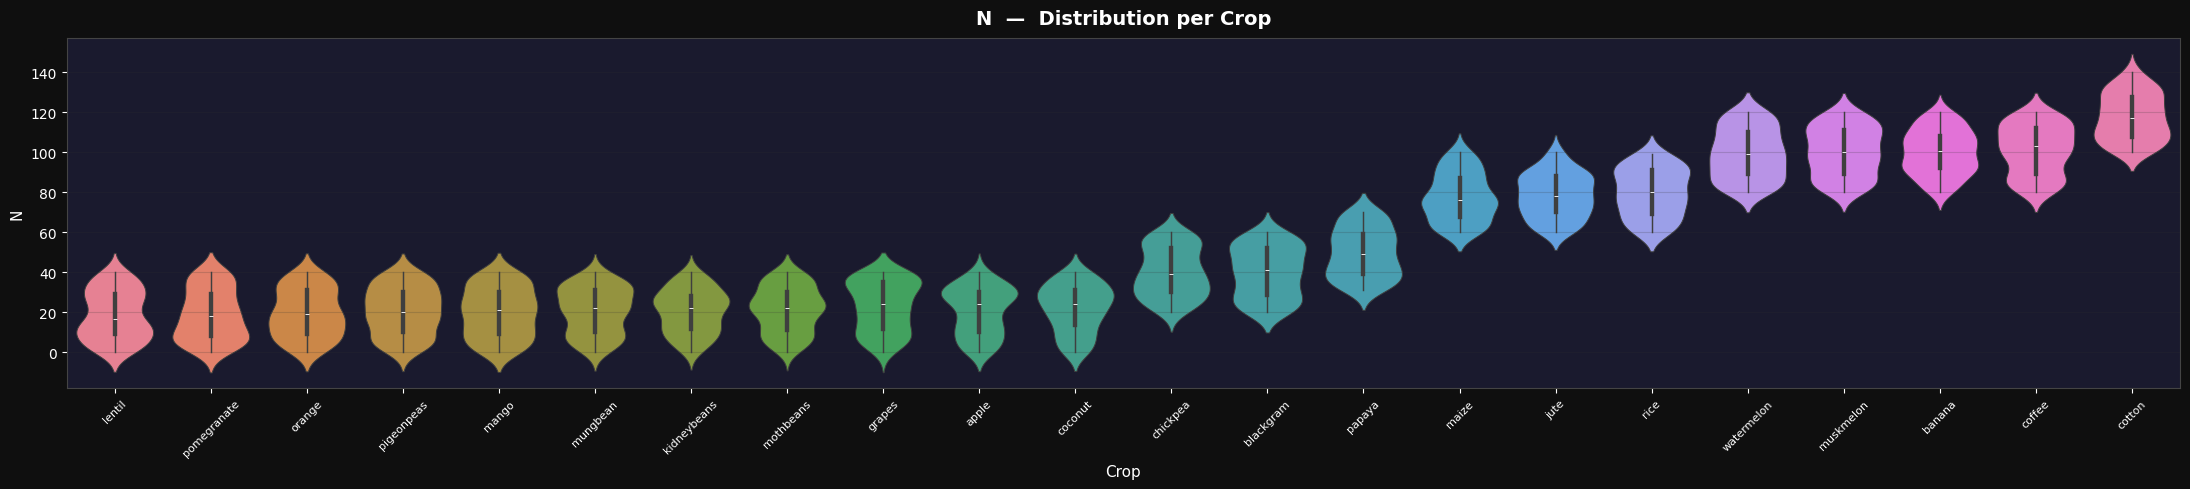

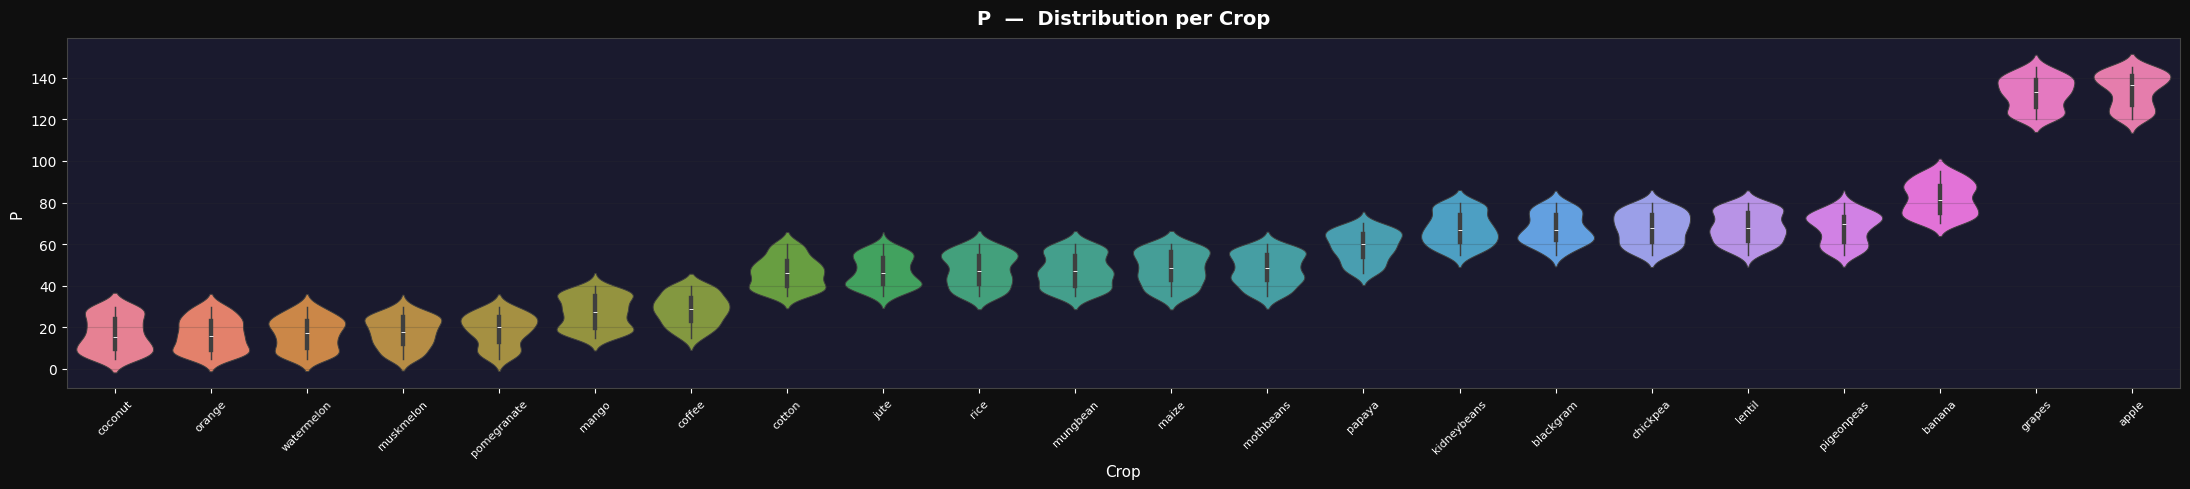

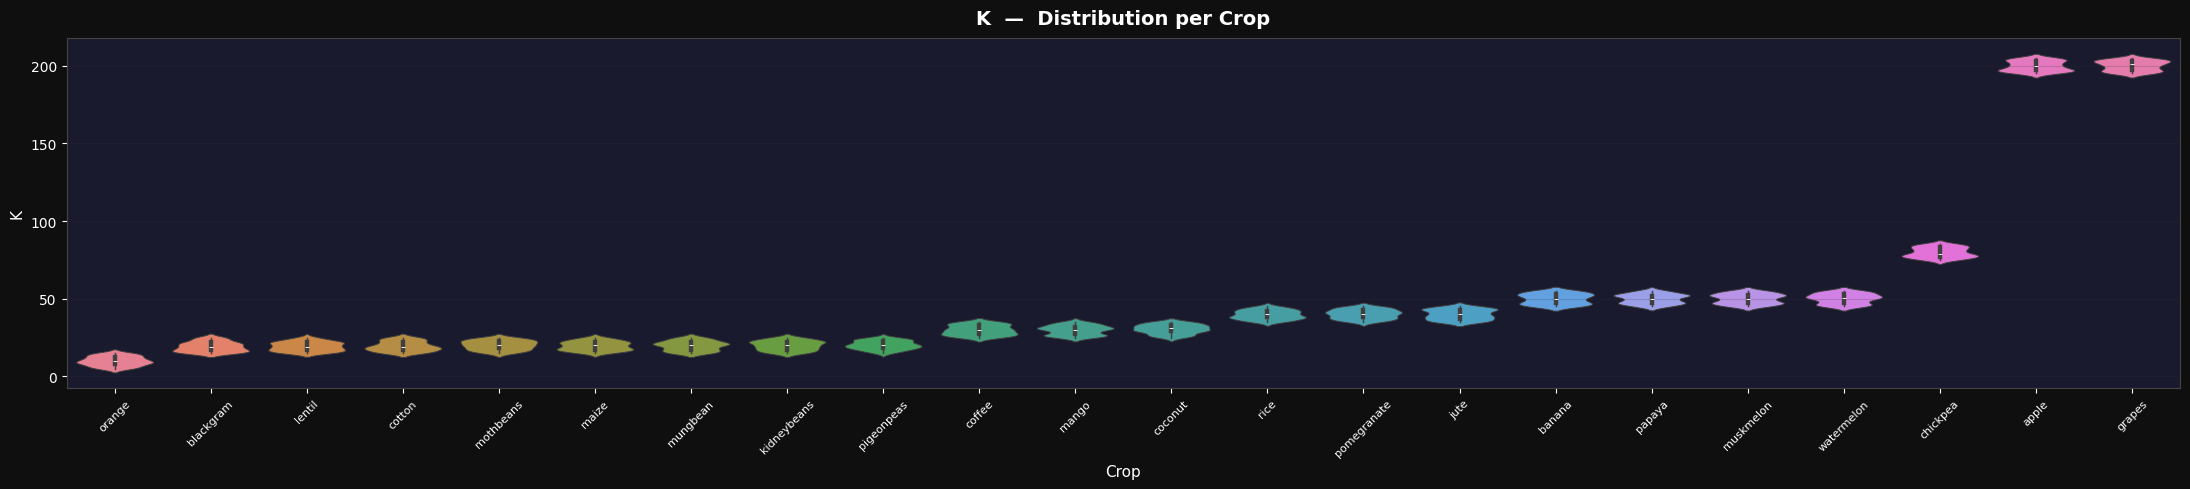

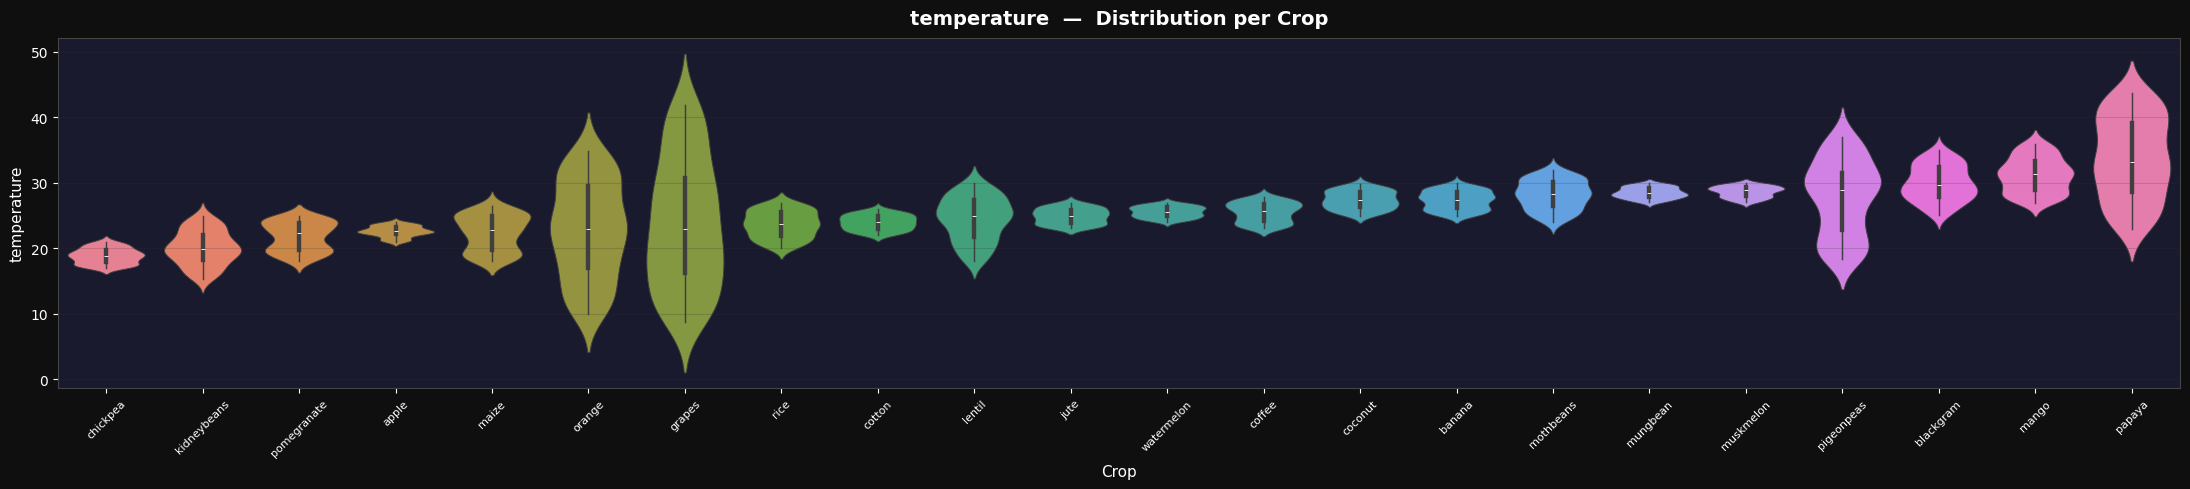

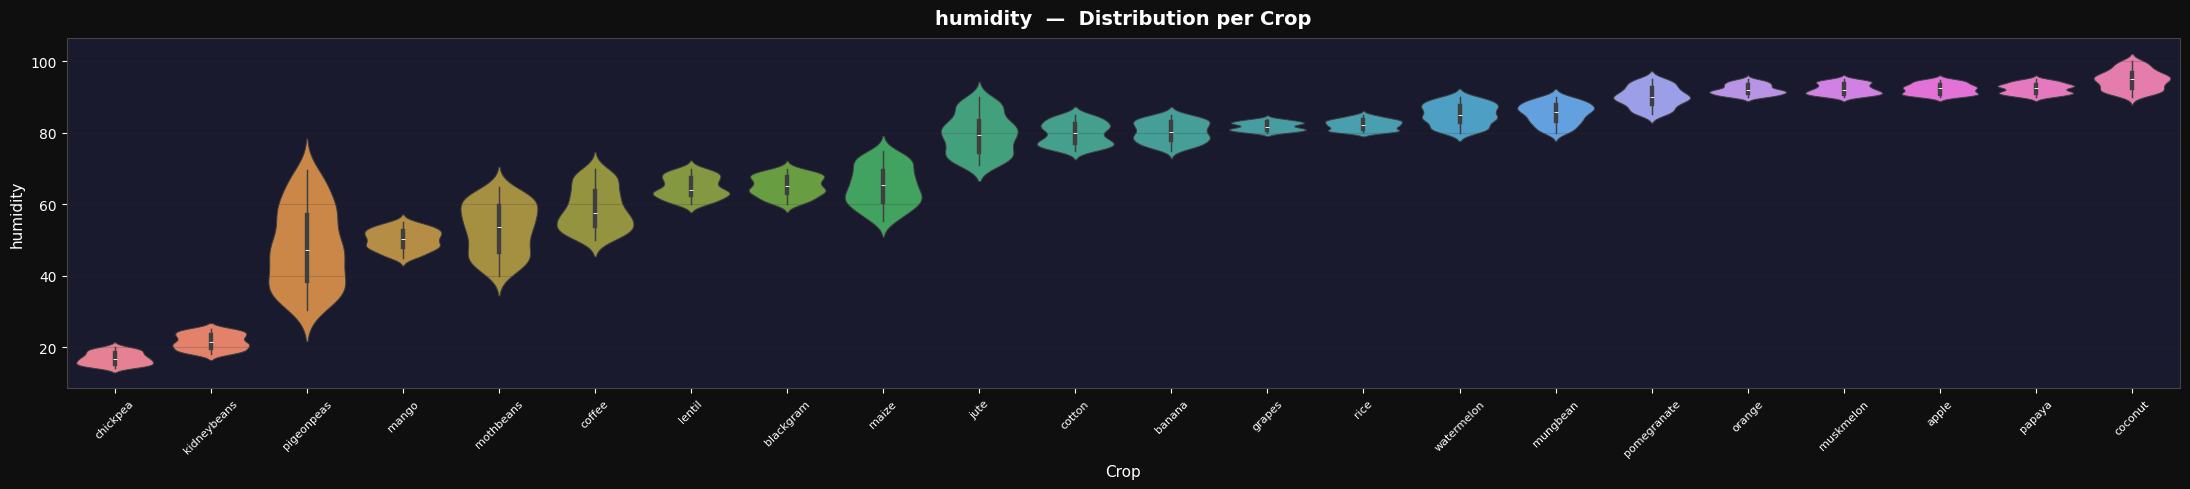

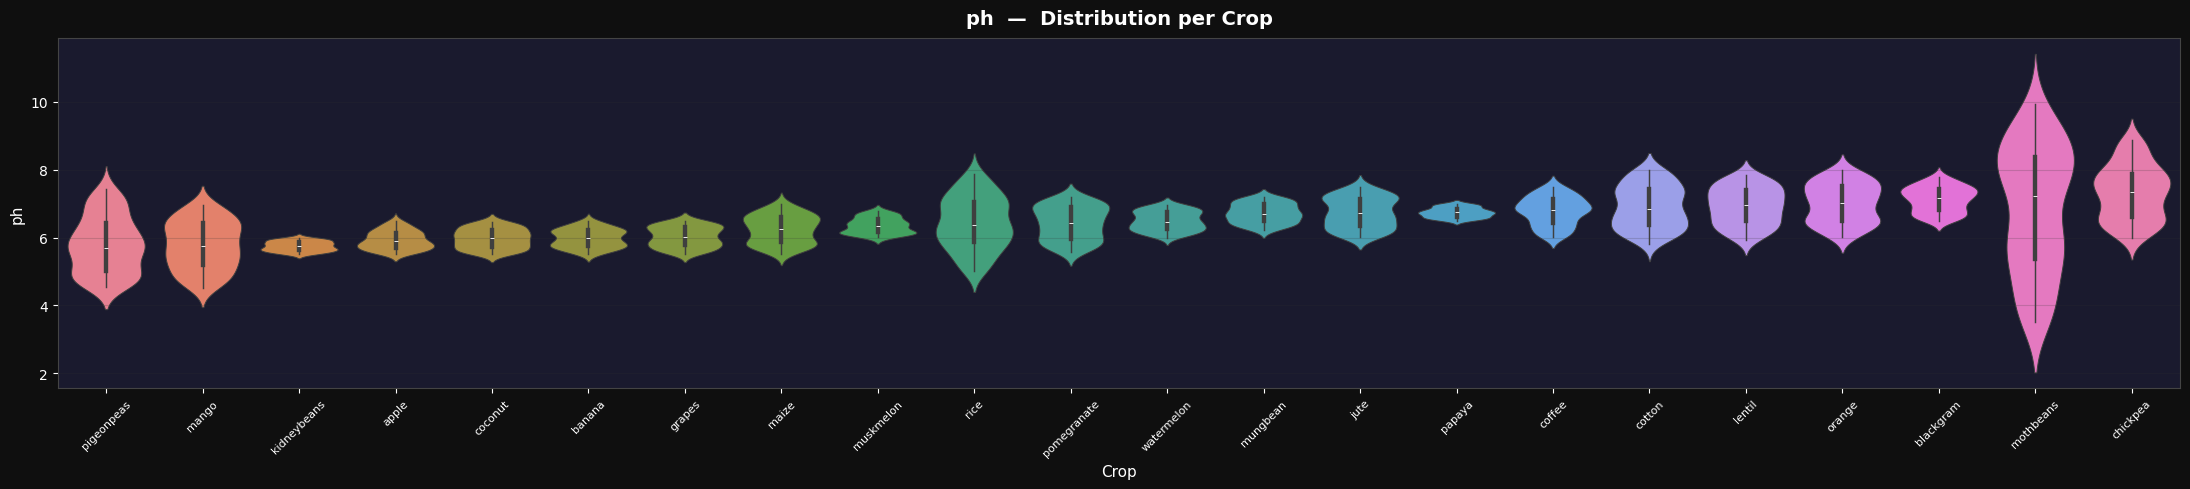

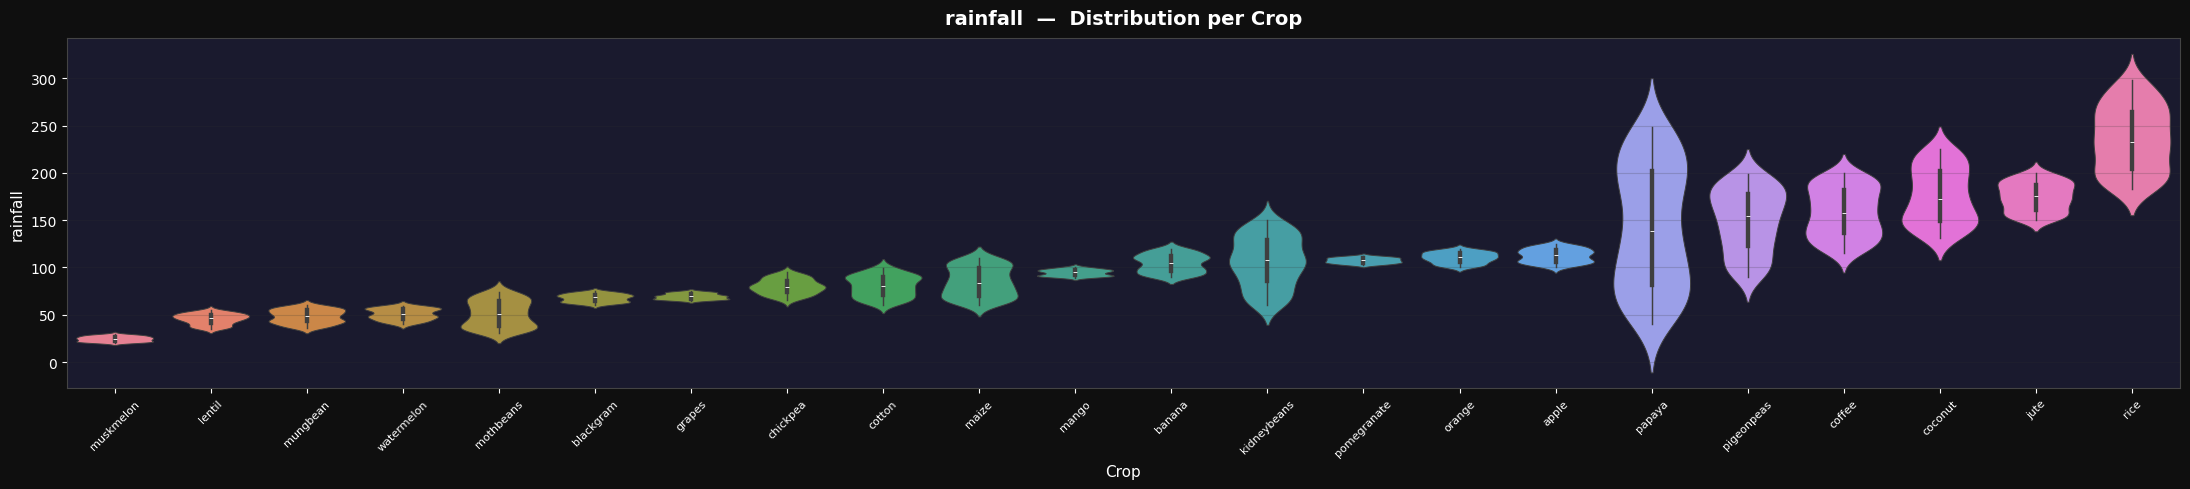

In [ ]:
# ── Feature Distributions per Crop (violin plots) ─────────────────────────
for feat in features:
    fig, ax = plt.subplots(figsize=(22, 5))
    fig.patch.set_facecolor('#0f0f0f')
    ax.set_facecolor('#1a1a2e')

    crop_order = df.groupby('label')[feat].median().sort_values().index.tolist()
    palette    = sns.color_palette("husl", len(crop_order))

    sns.violinplot(data=df, x='label', y=feat, order=crop_order,
                   palette=palette, inner='box', linewidth=0.7, ax=ax)

    ax.set_title(f'{feat}  —  Distribution per Crop', fontsize=14,
                  fontweight='bold', color='white', pad=10)
    ax.set_xlabel('Crop', fontsize=11)
    ax.set_ylabel(feat, fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.show()

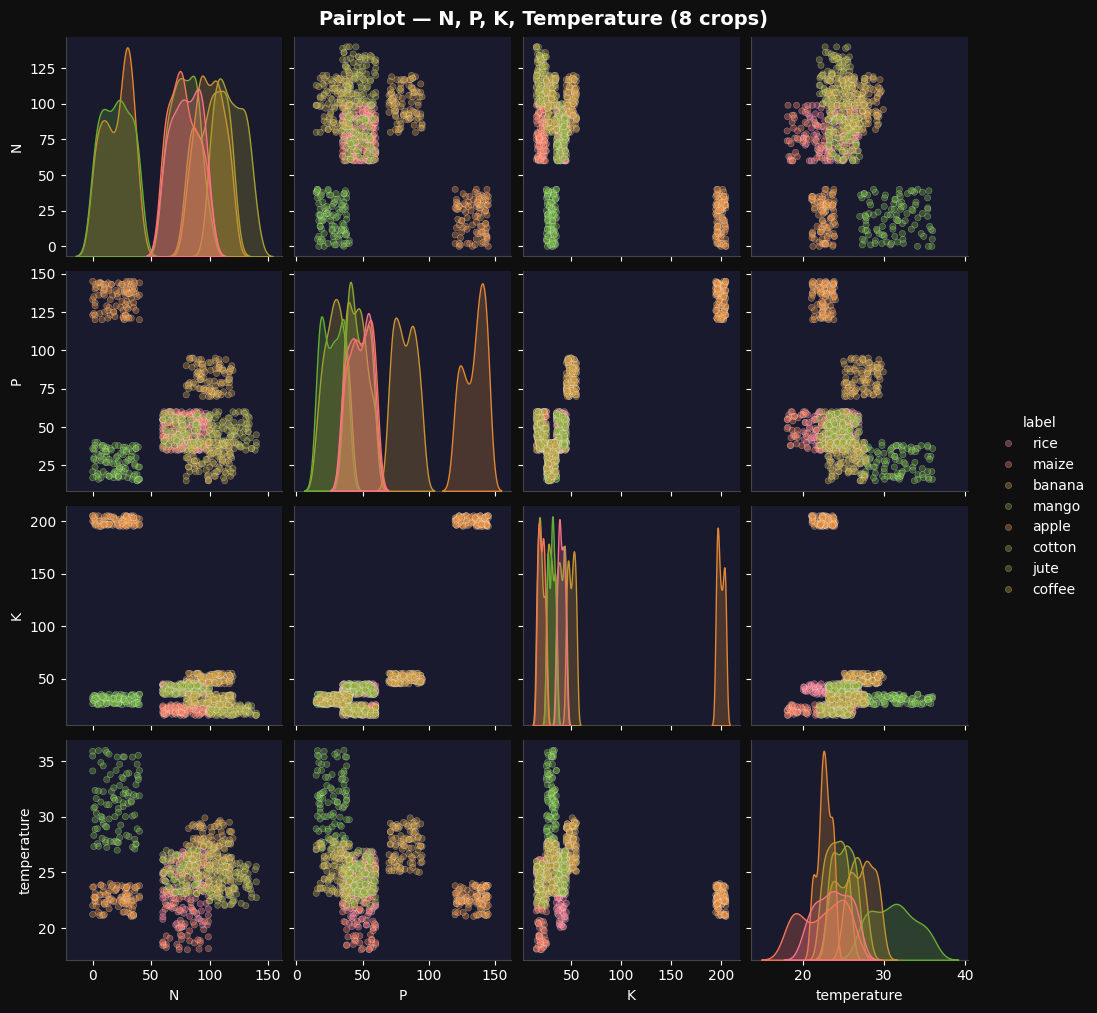

In [ ]:
# ── Pairplot (sample for speed) ────────────────────────────────────────────
# Sample 10 crops for a readable plot
sample_crops = ['rice', 'maize', 'apple', 'banana', 'coffee',
                'cotton', 'jute', 'mango', 'wheat', 'orange']
# Use only crops that exist in the dataset
sample_crops = [c for c in sample_crops if c in df['label'].unique()][:8]
df_sample = df[df['label'].isin(sample_crops)].copy()

pair_palette = {c: PALETTE[i] for i, c in enumerate(sample_crops)}

g = sns.pairplot(df_sample, hue='label', vars=features[:4],
                 palette=pair_palette, plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde')
g.figure.set_facecolor('#0f0f0f')
g.figure.suptitle('Pairplot — N, P, K, Temperature (8 crops)', fontsize=14,
                   fontweight='bold', color='white', y=1.01)
for ax in g.axes.flatten():
    if ax:
        ax.set_facecolor('#1a1a2e')
        ax.tick_params(colors='white')
plt.show()

In [ ]:
# ── Feature Matrix & Target Vector ────────────────────────────────────────
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[features].values
y_raw = df['label'].values

print(f"Feature matrix X shape : {X.shape}")
print(f"Target vector y shape  : {y_raw.shape}")

# ── Label Encoding ─────────────────────────────────────────────────────────
# Converts crop names (strings) to integers  e.g. "apple" → 0, "banana" → 1
le = LabelEncoder()
y  = le.fit_transform(y_raw)
class_names = le.classes_

print(f"\nClass Mapping (first 5):")
for i, name in enumerate(class_names[:5]):
    print(f"  {i:2d} → {name}")
print(f"  ... ({len(class_names)} total classes)")

# ── Feature Scaling ────────────────────────────────────────────────────────
# StandardScaler: (x - mean) / std  →  mean=0, std=1
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nBefore scaling  →  N: min={X[:,0].min()}, max={X[:,0].max()}")
print(f"After  scaling  →  N: min={X_scaled[:,0].min():.3f}, max={X_scaled[:,0].max():.3f}")

# ── Train / Test Split ─────────────────────────────────────────────────────
# 80% training, 20% testing, stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size : {X_train.shape[0]} samples  ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test  size : {X_test.shape[0]} samples  ({X_test.shape[0]/len(y)*100:.0f}%)")
print(f"\n✅ Preprocessing complete!")

Feature matrix X shape : (2200, 7)
Target vector y shape  : (2200,)

Class Mapping (first 5):
   0 → apple
   1 → banana
   2 → blackgram
   3 → chickpea
   4 → coconut
  ... (22 total classes)

Before scaling  →  N: min=0.0, max=140.0
After  scaling  →  N: min=-1.370, max=2.423

Train size : 1760 samples  (80%)
Test  size : 440 samples  (20%)

✅ Preprocessing complete!


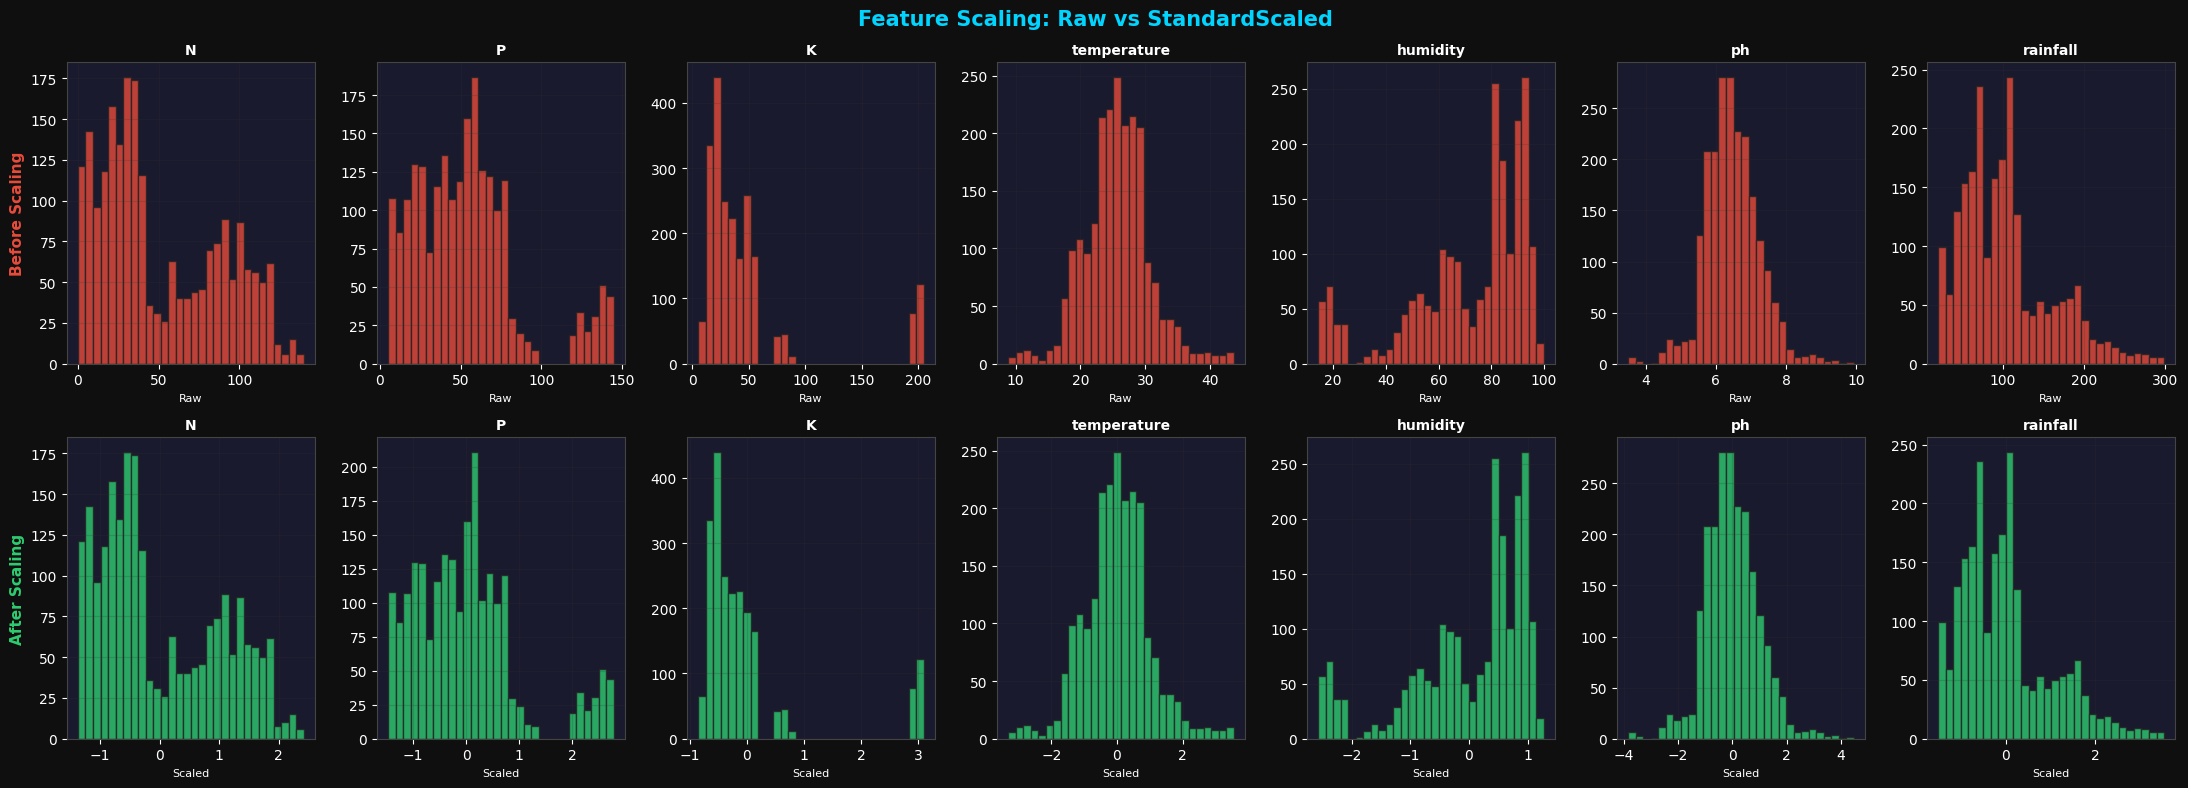

In [ ]:
# ── Visualize Preprocessing: Before vs After Scaling ──────────────────────
fig, axes = plt.subplots(2, 7, figsize=(22, 8))
fig.patch.set_facecolor('#0f0f0f')

for i, feat in enumerate(features):
    # Before
    axes[0, i].hist(X[:, i], bins=30, color='#e74c3c', alpha=0.8, edgecolor='#222')
    axes[0, i].set_title(feat, fontsize=10, fontweight='bold', color='white')
    axes[0, i].set_xlabel('Raw', fontsize=8)
    axes[0, i].grid(True, alpha=0.2)

    # After
    axes[1, i].hist(X_scaled[:, i], bins=30, color='#2ecc71', alpha=0.8, edgecolor='#222')
    axes[1, i].set_title(feat, fontsize=10, fontweight='bold', color='white')
    axes[1, i].set_xlabel('Scaled', fontsize=8)
    axes[1, i].grid(True, alpha=0.2)

axes[0, 0].set_ylabel('Before Scaling', fontsize=11, color='#e74c3c', fontweight='bold')
axes[1, 0].set_ylabel('After Scaling', fontsize=11, color='#2ecc71', fontweight='bold')

plt.suptitle('Feature Scaling: Raw vs StandardScaled', fontsize=15,
             fontweight='bold', color='#00d4ff')
plt.tight_layout()
plt.show()

In [ ]:
# ── Define All Models ─────────────────────────────────────────────────────
num_classes = len(class_names)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None,
        min_samples_split=2, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        objective='multi:softprob', num_class=num_classes,
        random_state=42, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective='multiclass', random_state=42, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.1,
        random_seed=42, verbose=0
    ),
    'SVM': SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, metric='euclidean', n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=15, min_samples_split=2,
        min_samples_leaf=1, random_state=42
    ),
    'Naive Bayes': GaussianNB()
}

print(f"✅ {len(models)} models defined and ready to train")
for name in models:
    print(f"   • {name}")

✅ 8 models defined and ready to train
   • Random Forest
   • XGBoost
   • LightGBM
   • CatBoost
   • SVM
   • KNN
   • Decision Tree
   • Naive Bayes


In [ ]:
# ── Train All Models & Collect Results ────────────────────────────────────
import time

results = {}
trained_models = {}

print("="*60)
print("  TRAINING MODELS  (this may take 1-2 minutes)")
print("="*60)

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    # 5-Fold Cross-Validation on training data
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=StratifiedKFold(n_splits=5, shuffle=True,
                                                   random_state=42),
                                scoring='accuracy', n_jobs=-1)

    results[name] = {
        'test_acc'  : acc * 100,
        'cv_mean'   : cv_scores.mean() * 100,
        'cv_std'    : cv_scores.std()  * 100,
        'train_time': elapsed,
        'y_pred'    : y_pred
    }
    trained_models[name] = model

    print(f"  {name:<20} | Test: {acc*100:6.2f}%  | "
          f"CV: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%  | "
          f"Time: {elapsed:.1f}s")

print("="*60)
print("✅ All models trained successfully!")

  TRAINING MODELS  (this may take 1-2 minutes)
  Random Forest        | Test:  99.32%  | CV: 99.38% ± 0.55%  | Time: 2.9s
  XGBoost              | Test:  99.32%  | CV: 99.15% ± 0.31%  | Time: 2.9s
  LightGBM             | Test:  99.55%  | CV: 99.32% ± 0.56%  | Time: 1.4s
  CatBoost             | Test:  99.55%  | CV: 98.92% ± 0.61%  | Time: 8.1s
  SVM                  | Test:  98.86%  | CV: 98.24% ± 0.49%  | Time: 0.2s
  KNN                  | Test:  97.95%  | CV: 96.53% ± 1.21%  | Time: 0.0s
  Decision Tree        | Test:  98.18%  | CV: 98.47% ± 0.69%  | Time: 0.0s
  Naive Bayes          | Test:  99.55%  | CV: 99.49% ± 0.42%  | Time: 0.0s
✅ All models trained successfully!


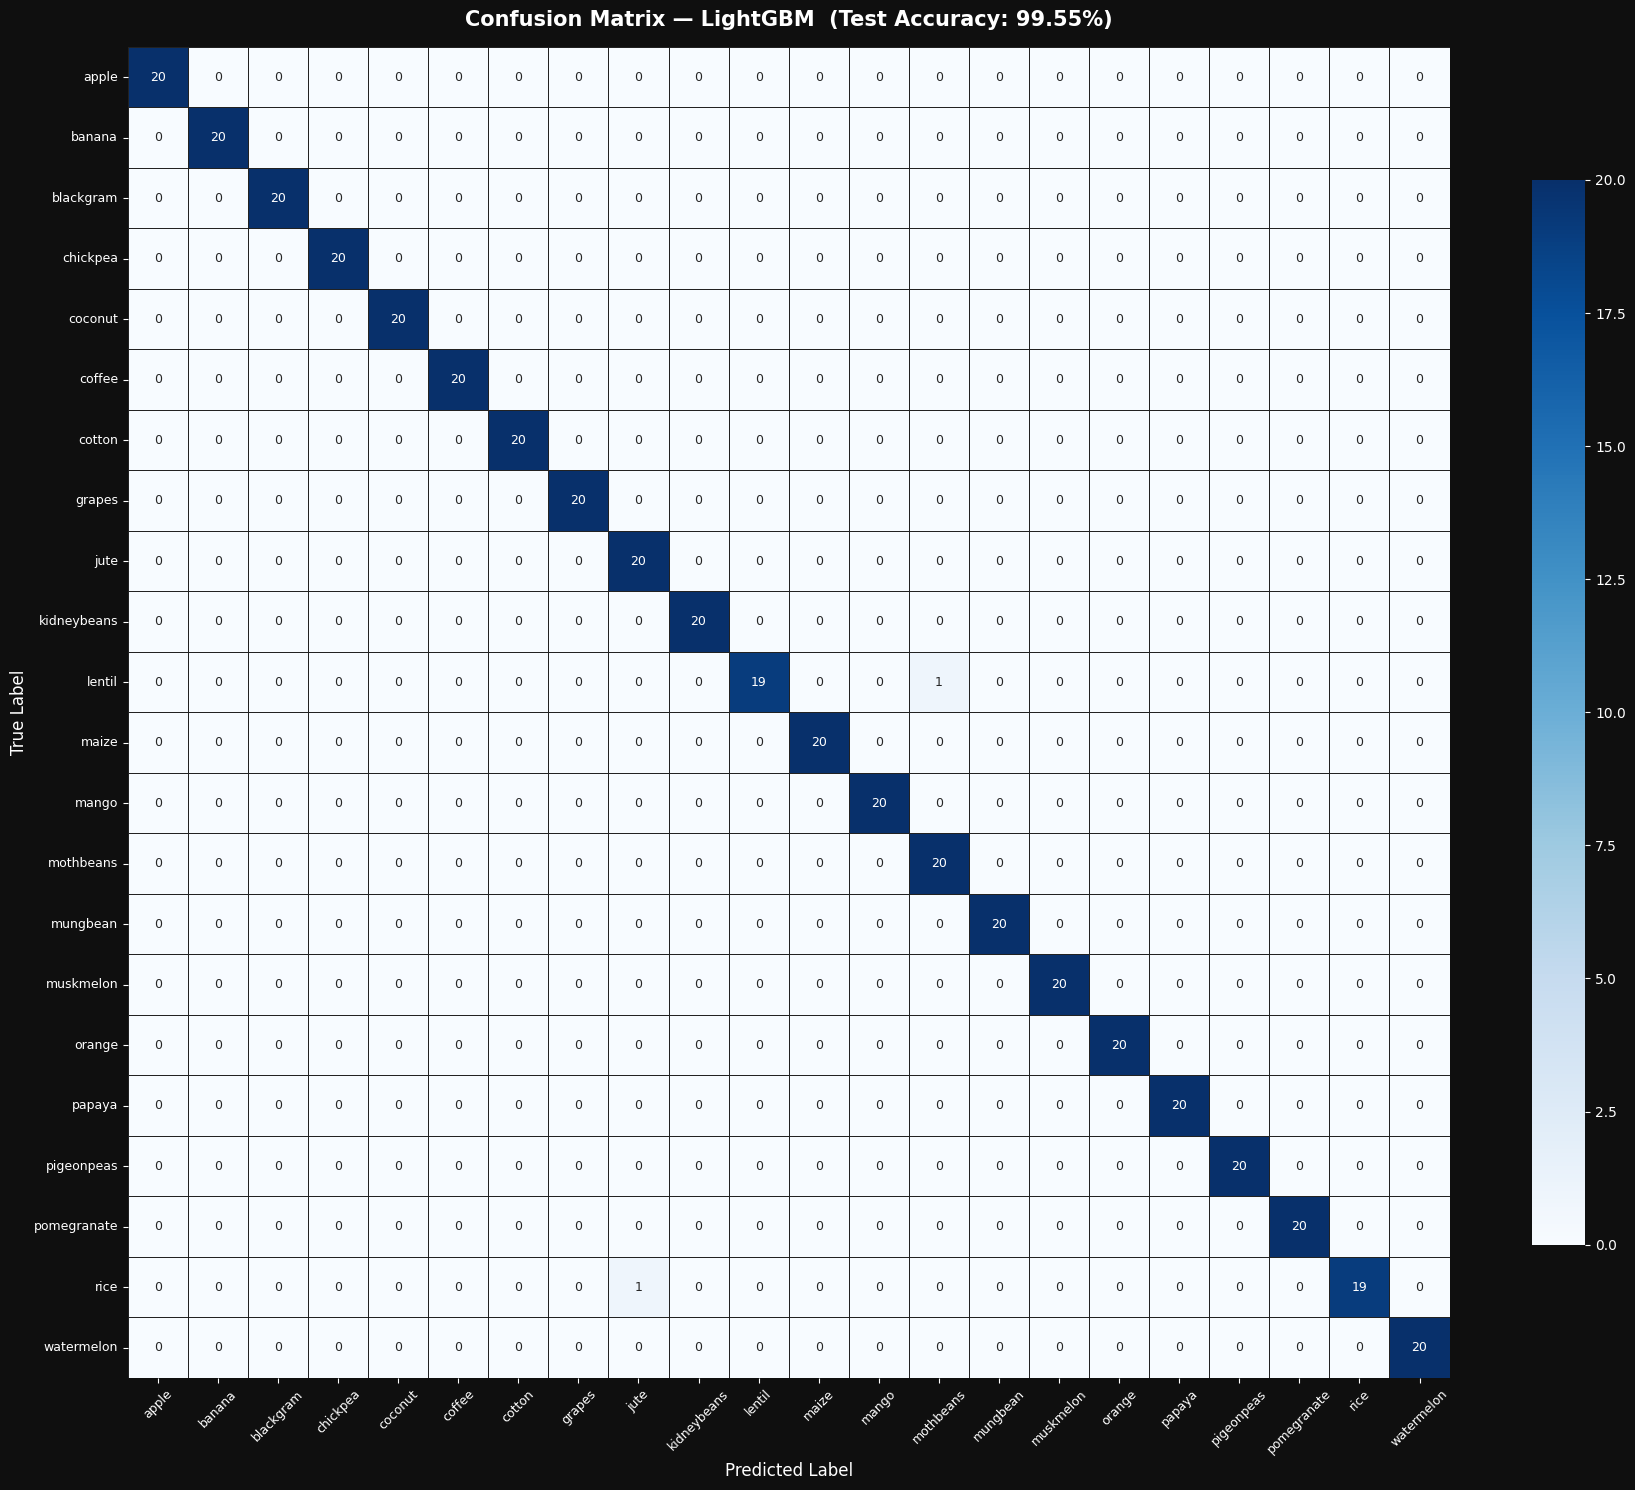

In [ ]:
# ── Full Confusion Matrix for Best Model ──────────────────────────────────
best_model_name = max(results, key=lambda m: results[m]['test_acc'])
best_y_pred     = results[best_model_name]['y_pred']
cm              = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(18, 15))
fig.patch.set_facecolor('#0f0f0f')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='#222',
            annot_kws={'size': 9},
            ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title(f'Confusion Matrix — {best_model_name}  (Test Accuracy: {results[best_model_name]["test_acc"]:.2f}%)',
             fontsize=15, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12, color='white')
ax.set_ylabel('True Label',      fontsize=12, color='white')
ax.tick_params(axis='x', rotation=45, labelsize=9, colors='white')
ax.tick_params(axis='y', rotation=0,  labelsize=9, colors='white')
plt.tight_layout()
plt.show()

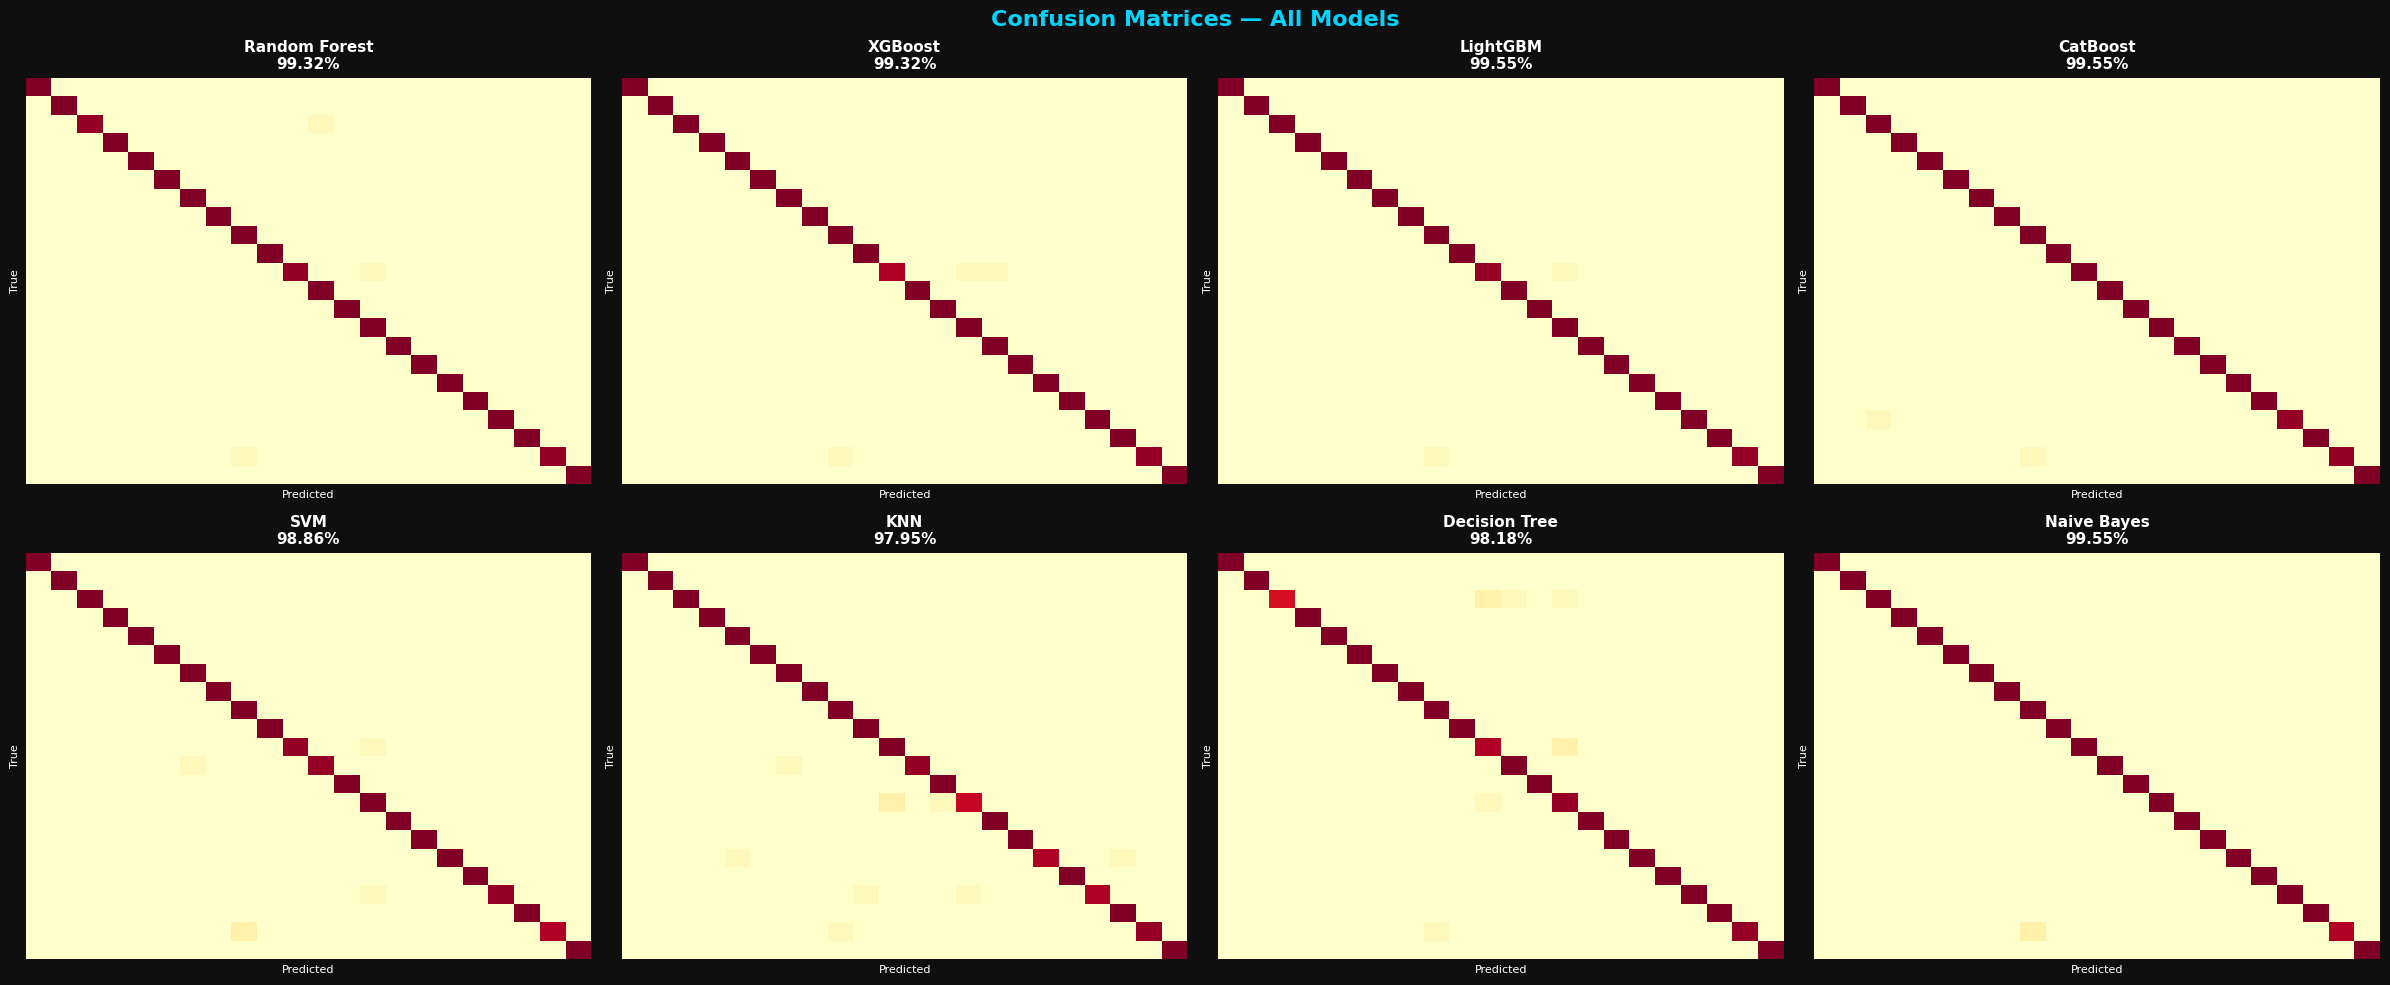

In [ ]:
# ── Mini Confusion Matrices for All Models (2×4 grid) ────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm_m = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm_m, ax=axes[idx], cmap='YlOrRd',
                xticklabels=False, yticklabels=False,
                linewidths=0, cbar=False)
    axes[idx].set_title(f"{name}\n{res['test_acc']:.2f}%",
                         fontsize=11, fontweight='bold', color='white')
    axes[idx].set_xlabel('Predicted', fontsize=8)
    axes[idx].set_ylabel('True',      fontsize=8)

plt.suptitle('Confusion Matrices — All Models', fontsize=16,
             fontweight='bold', color='#00d4ff')
plt.tight_layout()
plt.show()

Classification Report — LightGBM
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00     

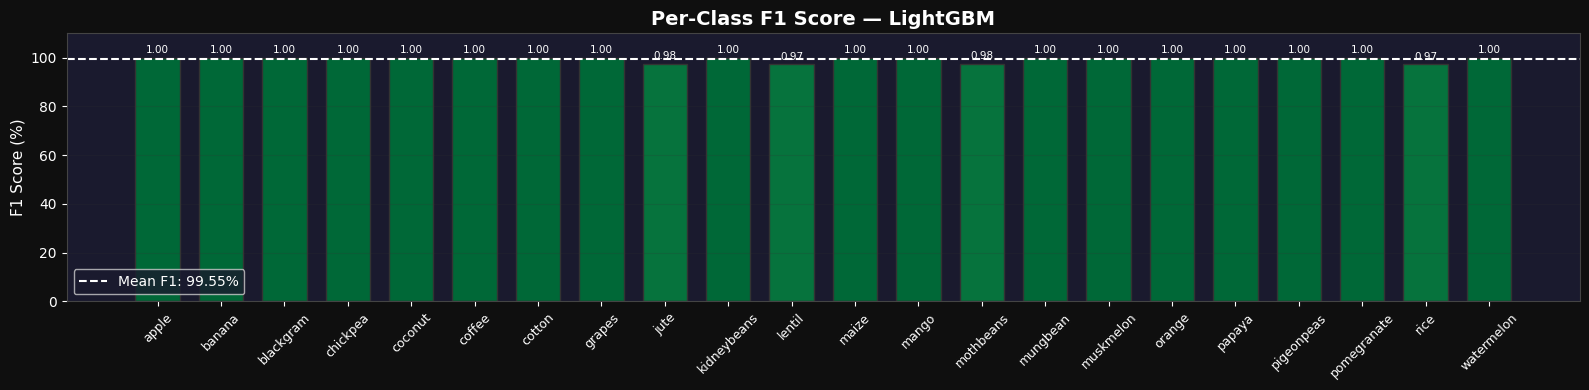

In [ ]:
# ── Detailed Per-Class Report ─────────────────────────────────────────────
print(f"Classification Report — {best_model_name}")
print("="*65)
print(classification_report(y_test, best_y_pred, target_names=class_names))

# ── Per-Class F1 Score Heatmap ─────────────────────────────────────────────
from sklearn.metrics import f1_score
f1_scores = f1_score(y_test, best_y_pred, average=None)

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor('#0f0f0f')

bar_colors = plt.cm.RdYlGn(f1_scores)
bars = ax.bar(class_names, f1_scores * 100, color=bar_colors, edgecolor='#333', width=0.7)
ax.axhline(y=f1_scores.mean() * 100, color='white', linestyle='--',
           linewidth=1.5, label=f'Mean F1: {f1_scores.mean()*100:.2f}%')
ax.set_ylim(0, 110)
ax.set_title(f'Per-Class F1 Score — {best_model_name}', fontsize=14,
              fontweight='bold', color='white')
ax.set_ylabel('F1 Score (%)', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, axis='y')

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val * 100 + 1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, color='white')

plt.tight_layout()
plt.show()

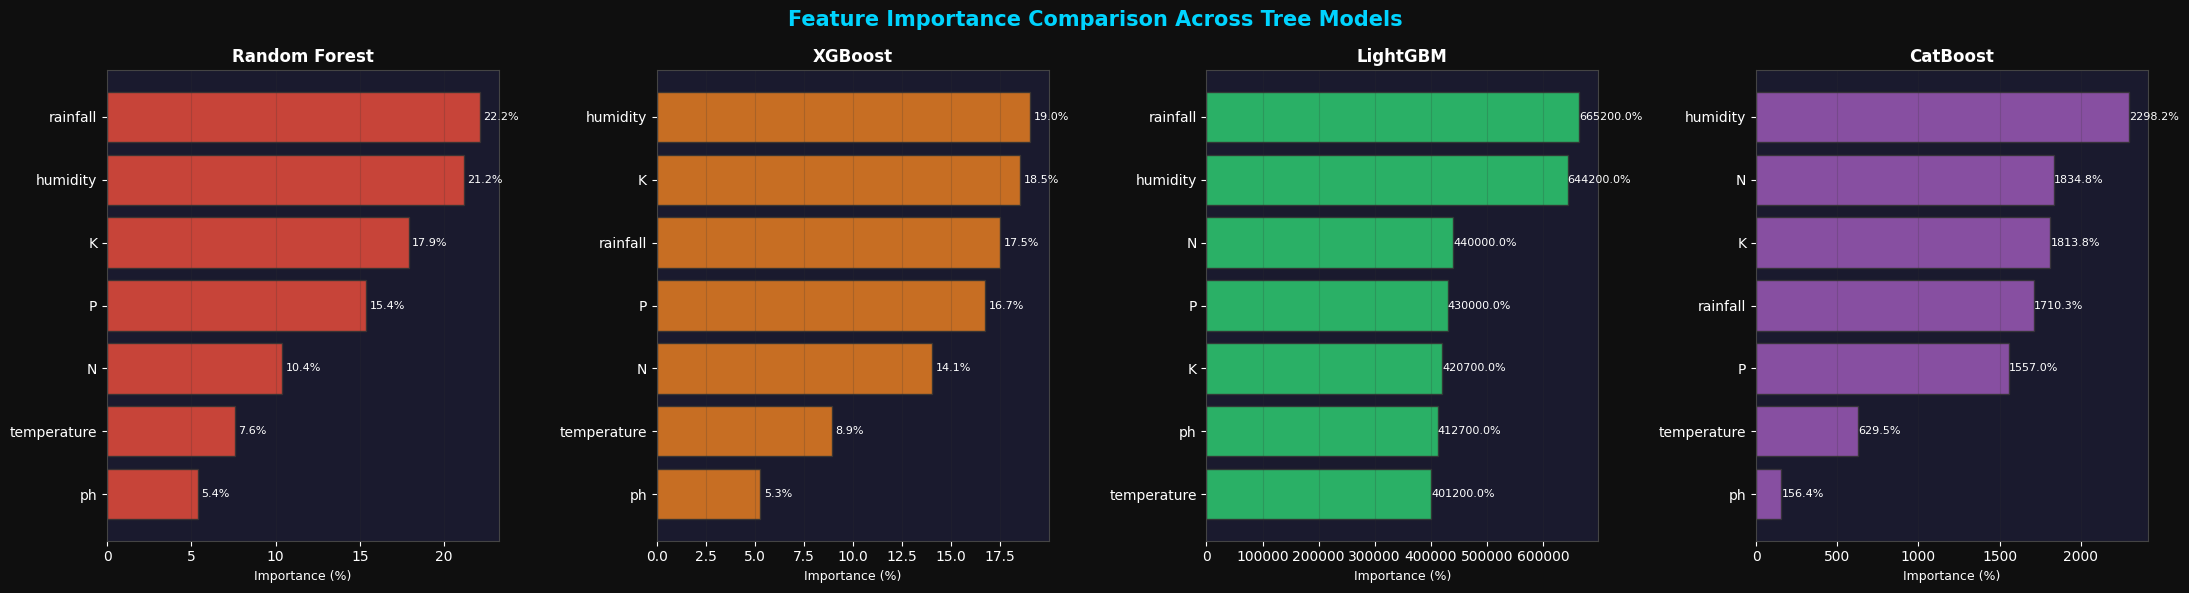

In [ ]:
# ── Feature Importance from Tree-Based Models ─────────────────────────────
tree_models = {
    'Random Forest' : trained_models['Random Forest'],
    'XGBoost'       : trained_models['XGBoost'],
    'LightGBM'      : trained_models['LightGBM'],
    'CatBoost'      : trained_models['CatBoost'],
}

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.patch.set_facecolor('#0f0f0f')

model_colors = ['#e74c3c', '#e67e22', '#2ecc71', '#9b59b6']

for idx, (name, model) in enumerate(tree_models.items()):
    fi = model.feature_importances_
    sorted_fi_idx = np.argsort(fi)
    sorted_feats  = [features[i] for i in sorted_fi_idx]
    sorted_vals   = fi[sorted_fi_idx]

    axes[idx].barh(sorted_feats, sorted_vals * 100,
                   color=model_colors[idx], alpha=0.85, edgecolor='#333')
    axes[idx].set_title(name, fontsize=12, fontweight='bold', color='white')
    axes[idx].set_xlabel('Importance (%)', fontsize=9)
    axes[idx].grid(True, alpha=0.2, axis='x')

    for bar, val in zip(axes[idx].patches, sorted_vals):
        axes[idx].text(val*100 + 0.2, bar.get_y() + bar.get_height()/2,
                       f'{val*100:.1f}%', va='center', fontsize=8, color='white')

plt.suptitle('Feature Importance Comparison Across Tree Models',
             fontsize=15, fontweight='bold', color='#00d4ff')
plt.tight_layout()
plt.show()

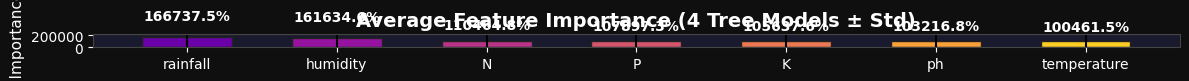

In [ ]:
# ── Aggregated Feature Importance (Average across 4 tree models) ──────────
all_fi = np.stack([trained_models[n].feature_importances_
                   for n in ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']])
mean_fi = all_fi.mean(axis=0)
std_fi  = all_fi.std(axis=0)

sorted_idx = np.argsort(mean_fi)[::-1]
sorted_features = [features[i] for i in sorted_idx]
sorted_mean     = mean_fi[sorted_idx]
sorted_std      = std_fi[sorted_idx]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

gradient = plt.cm.plasma(np.linspace(0.2, 0.9, len(features)))
bars = ax.bar(sorted_features, sorted_mean * 100,
              color=gradient, edgecolor='#222', width=0.6,
              yerr=sorted_std * 100, capsize=6,
              error_kw={'color': 'white', 'linewidth': 1.5})

ax.set_title('Average Feature Importance (4 Tree Models ± Std)',
              fontsize=14, fontweight='bold', color='white')
ax.set_ylabel('Mean Importance (%)', fontsize=11)
ax.set_ylim(0, max(sorted_mean * 100) * 1.3)
ax.grid(True, alpha=0.2, axis='y')

for bar, val, std in zip(bars, sorted_mean, sorted_std):
    ax.text(bar.get_x() + bar.get_width()/2, val*100 + std*100 + 0.5,
            f'{val*100:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

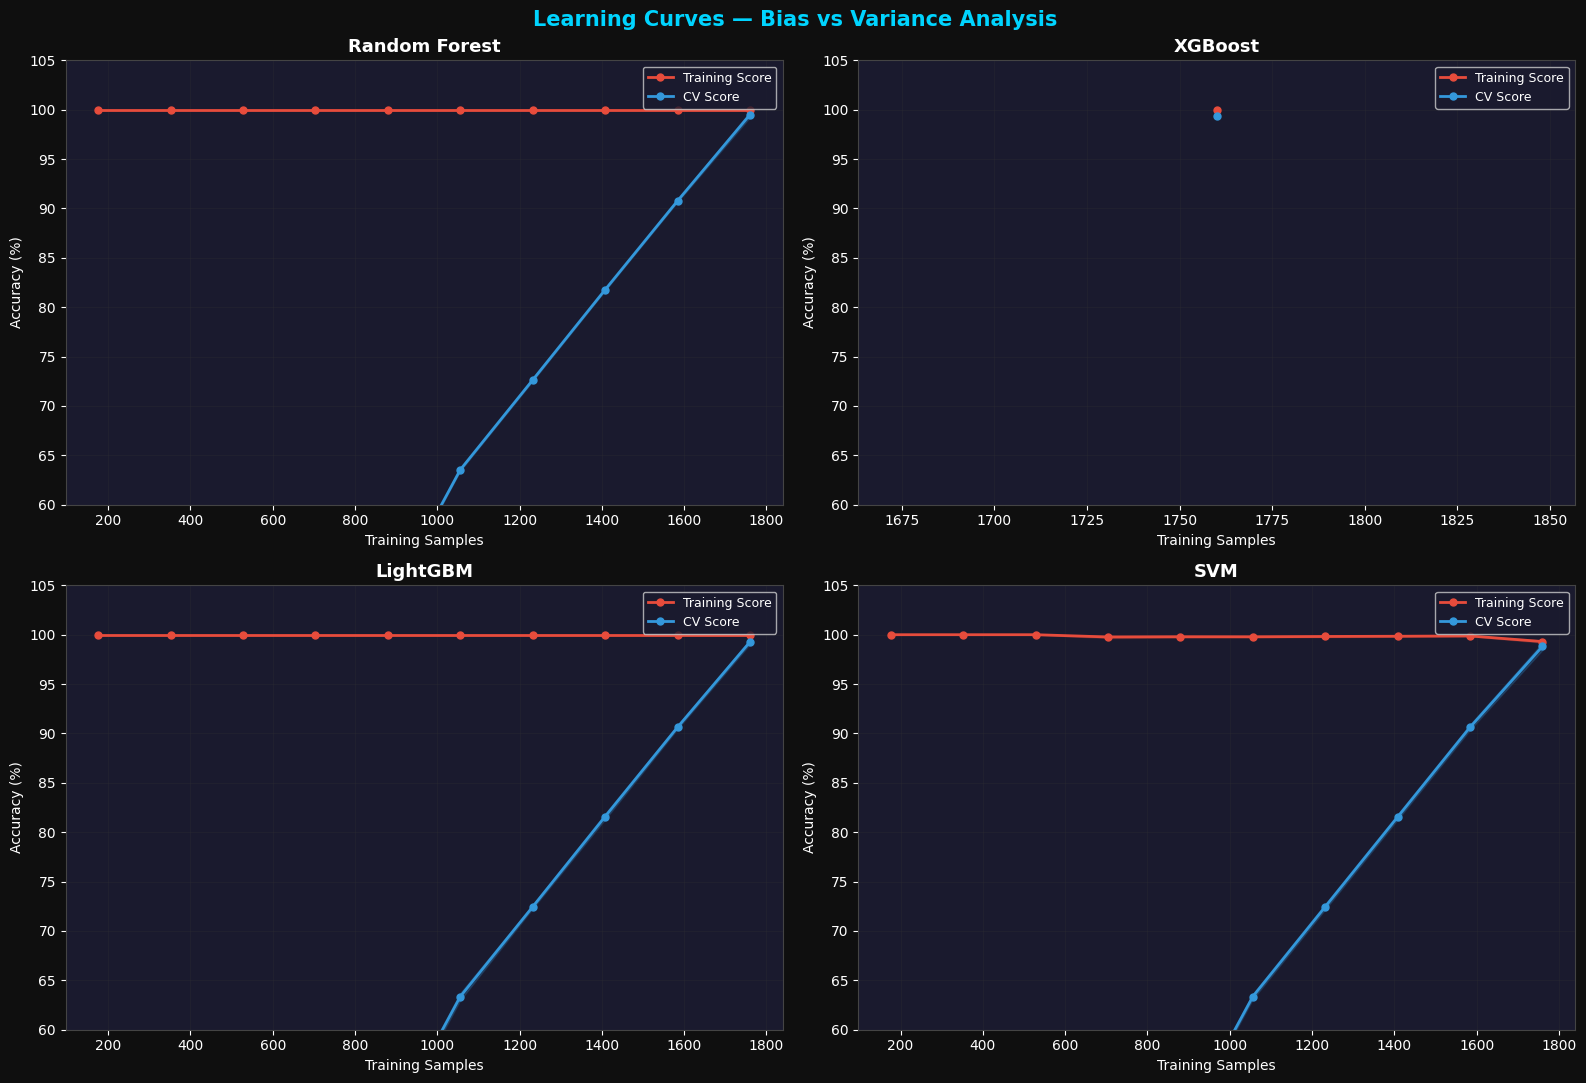

In [ ]:
# ── Learning Curves for Best Models ───────────────────────────────────────
lc_models = {
    'Random Forest' : trained_models['Random Forest'],
    'XGBoost'       : trained_models['XGBoost'],
    'LightGBM'      : trained_models['LightGBM'],
    'SVM'           : trained_models['SVM'],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

for idx, (name, model) in enumerate(lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_scaled, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy', n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1) * 100
    train_std  = train_scores.std(axis=1)  * 100
    val_mean   = val_scores.mean(axis=1)   * 100
    val_std    = val_scores.std(axis=1)    * 100

    ax = axes[idx]
    ax.plot(train_sizes, train_mean, 'o-', color='#e74c3c', linewidth=2,
            label='Training Score', markersize=5)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='#e74c3c')
    ax.plot(train_sizes, val_mean, 'o-', color='#3498db', linewidth=2,
            label='CV Score', markersize=5)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='#3498db')

    ax.set_title(name, fontsize=13, fontweight='bold', color='white')
    ax.set_xlabel('Training Samples', fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_ylim(60, 105)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle('Learning Curves — Bias vs Variance Analysis',
             fontsize=15, fontweight='bold', color='#00d4ff')
plt.tight_layout()
plt.show()

In [ ]:
# ── Build Stacking Ensemble ────────────────────────────────────────────────
# Stacking = use predictions from base models as input to a meta-learner
print("Building Stacking Ensemble...")

estimators = [
    ('rf',       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('xgb',      XGBClassifier(n_estimators=200, random_state=42, verbosity=0,
                                use_label_encoder=False, eval_metric='mlogloss')),
    ('lgbm',     LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)),
    ('catboost', CatBoostClassifier(iterations=200, random_seed=42, verbose=0)),
    ('svm',      SVC(kernel='rbf', C=10, probability=True, random_state=42)),
]

meta_learner = LogisticRegression(C=1.0, max_iter=1000, multi_class='multinomial',
                                   solver='lbfgs', random_state=42)

stacked_clf = StackingClassifier(
    estimators    = estimators,
    final_estimator = meta_learner,
    cv            = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method  = 'predict_proba',
    passthrough   = False,   # False = only use model predictions, not raw features
    n_jobs        = -1
)

stacked_clf.fit(X_train, y_train)
y_pred_stack = stacked_clf.predict(X_test)
stack_acc    = accuracy_score(y_test, y_pred_stack) * 100

print(f"\n Stacking Ensemble Accuracy: {stack_acc:.2f}%")
print(f"   Best Single Model          : {best_model_name} → {results[best_model_name]['test_acc']:.2f}%")
print(f"   Improvement                : +{stack_acc - results[best_model_name]['test_acc']:.2f}%")

# Add stacking to results
results['Stacking Ensemble'] = {
    'test_acc'  : stack_acc,
    'cv_mean'   : 0,
    'cv_std'    : 0,
    'train_time': 0,
    'y_pred'    : y_pred_stack
}

Building Stacking Ensemble...

 Stacking Ensemble Accuracy: 99.55%
   Best Single Model          : LightGBM → 99.55%
   Improvement                : +0.00%


In [ ]:
# ── Final Model Scoreboard ─────────────────────────────────────────────────
print("\n" + "="*60)
print("  FINAL MODEL SCOREBOARD")
print("="*60)
all_names = list(results.keys())
all_accs  = [results[m]['test_acc'] for m in all_names]
sorted_pairs = sorted(zip(all_accs, all_names), reverse=True)

for rank, (acc, name) in enumerate(sorted_pairs, 1):
    medal = "🥇" if rank == 1 else ("🥈" if rank == 2 else ("🥉" if rank == 3 else "  "))
    bar = "█" * int(acc / 5)
    print(f"  {medal} #{rank:2d}  {name:<22} {acc:6.2f}%  {bar}")

print("="*60)


  FINAL MODEL SCOREBOARD
  🥇 # 1  Stacking Ensemble       99.55%  ███████████████████
  🥈 # 2  Naive Bayes             99.55%  ███████████████████
  🥉 # 3  LightGBM                99.55%  ███████████████████
     # 4  CatBoost                99.55%  ███████████████████
     # 5  XGBoost                 99.32%  ███████████████████
     # 6  Random Forest           99.32%  ███████████████████
     # 7  SVM                     98.86%  ███████████████████
     # 8  Decision Tree           98.18%  ███████████████████
     # 9  KNN                     97.95%  ███████████████████


In [ ]:
# ── SHAP Setup ────────────────────────────────────────────────────────────
# We use Random Forest for SHAP (TreeExplainer is fast and exact for tree models)
rf_model    = trained_models['Random Forest']
explainer   = shap.TreeExplainer(rf_model)

# Compute SHAP values on test set (may take 30-60 seconds)
print("Computing SHAP values... (may take ~30 seconds)")
shap_values = explainer.shap_values(X_test)
# shap_values is a list of arrays: one per class
# shape: [n_classes][n_samples, n_features]
print(f"✅ SHAP values computed!")
print(f"   Shape per class : {shap_values[0].shape}")
print(f"   Classes         : {len(shap_values)}")

Computing SHAP values... (may take ~30 seconds)
✅ SHAP values computed!
   Shape per class : (7, 22)
   Classes         : 440


Plot 1: Global SHAP Feature Importance


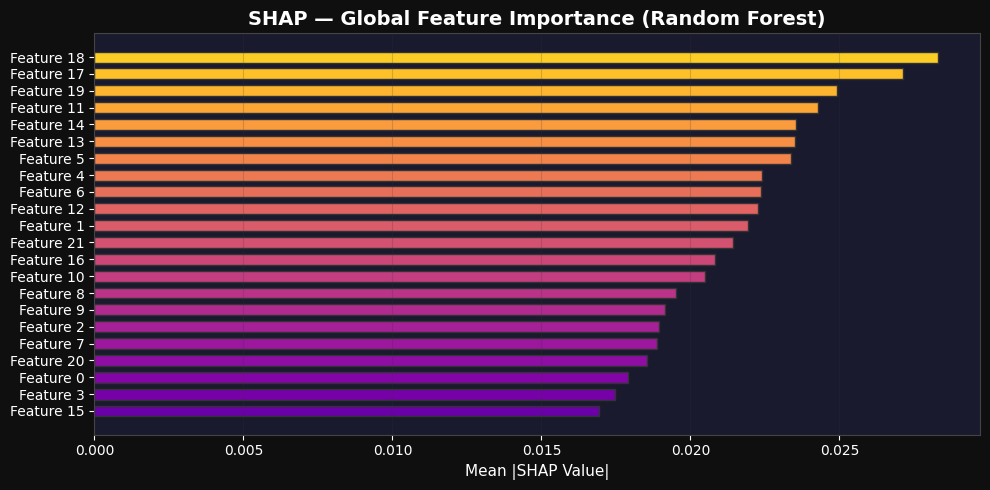

In [ ]:
print("Plot 1: Global SHAP Feature Importance")

# ✅ Convert shap_values → numpy
shap_array = np.array(shap_values)   # (n_classes, n_samples, n_features)

# ✅ Mean across classes
mean_abs_shap = np.mean(np.abs(shap_array), axis=0)   # (n_samples, n_features)

# ✅ Global importance
fi_means = mean_abs_shap.mean(axis=0)   # (n_features,)

# ✅ ALWAYS derive feature count from SHAP (most reliable)
n_features = fi_means.shape[0]
features = np.array([f"Feature {i}" for i in range(n_features)])

# ✅ Sort
sorted_fi = np.argsort(fi_means)

# 🎨 Colors
bar_colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_features))

# 🎯 Plot
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

ax.barh(
    features[sorted_fi],
    fi_means[sorted_fi],
    color=bar_colors,
    edgecolor='#333',
    height=0.65
)

# 🎨 Styling
ax.set_title('SHAP — Global Feature Importance (Random Forest)',
             fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='x', colors='white')
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

Plot 2: SHAP Beeswarm — top 5 crops


  0%|          | 0/20 [00:00<?, ?it/s]

  → Crop: apple
SHAP shape: (20, 7)
X shape   : (20, 7)


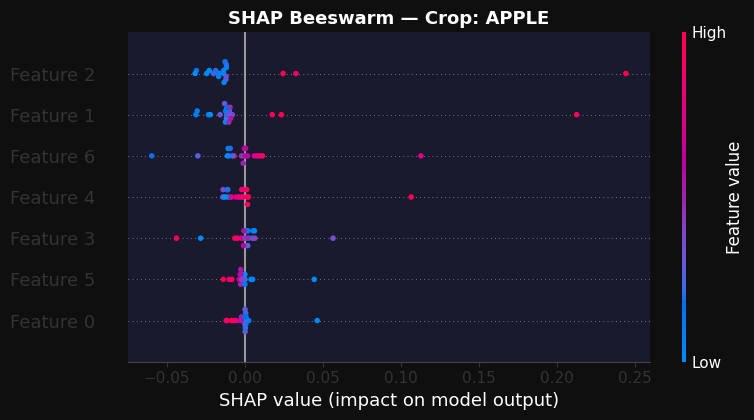

  → Crop: banana
SHAP shape: (20, 7)
X shape   : (20, 7)


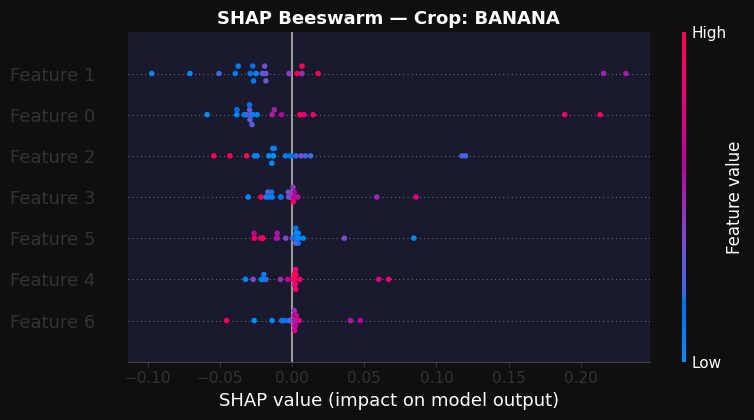

  → Crop: blackgram
SHAP shape: (20, 7)
X shape   : (20, 7)


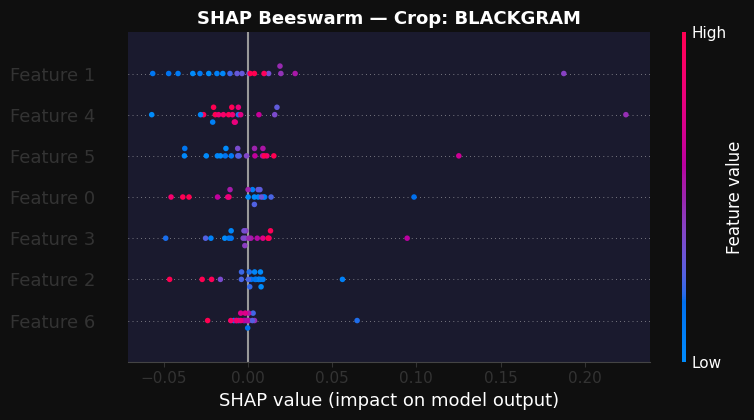

  → Crop: chickpea
SHAP shape: (20, 7)
X shape   : (20, 7)


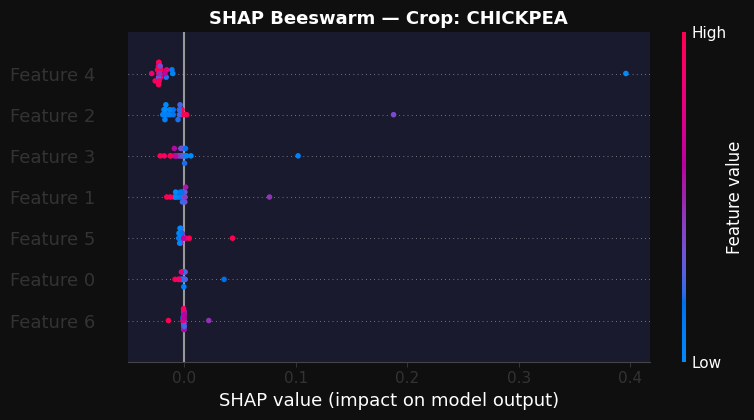

  → Crop: coconut
SHAP shape: (20, 7)
X shape   : (20, 7)


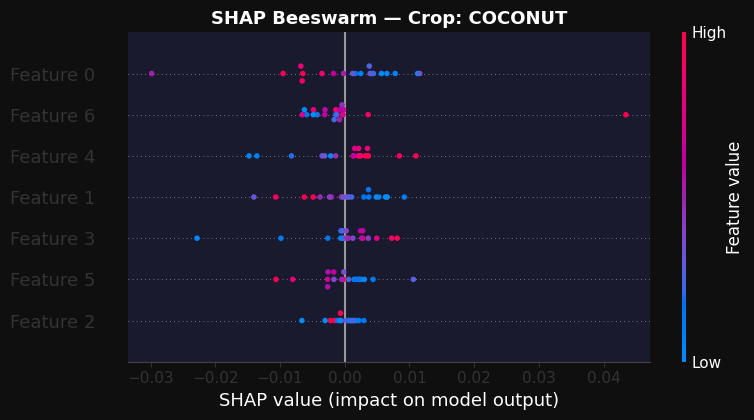

In [ ]:
print("Plot 2: SHAP Beeswarm — top 5 crops")

import shap
import numpy as np
import matplotlib.pyplot as plt


try:
    X_processed = X_test_scaled
except:
    X_processed = X_test


X_sample = X_processed[:20]

explainer = shap.KernelExplainer(model.predict_proba, X_sample)
shap_values = explainer.shap_values(X_sample)


n_features = X_sample.shape[1]
features = [f"Feature {i}" for i in range(n_features)]


if isinstance(shap_values, list):

    shap_list = shap_values
else:

    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

top_5_class_names = class_names[:5]

for class_idx, crop in enumerate(top_5_class_names):
    print(f"  → Crop: {crop}")

    print("SHAP shape:", shap_list[class_idx].shape)
    print("X shape   :", X_sample.shape)

    shap.summary_plot(
        shap_list[class_idx],   # ✅ FIXED
        X_sample,
        feature_names=features,
        show=False,
        plot_type='dot',
        max_display=7,
        color_bar=True
    )

    plt.title(f'SHAP Beeswarm — Crop: {crop.upper()}',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

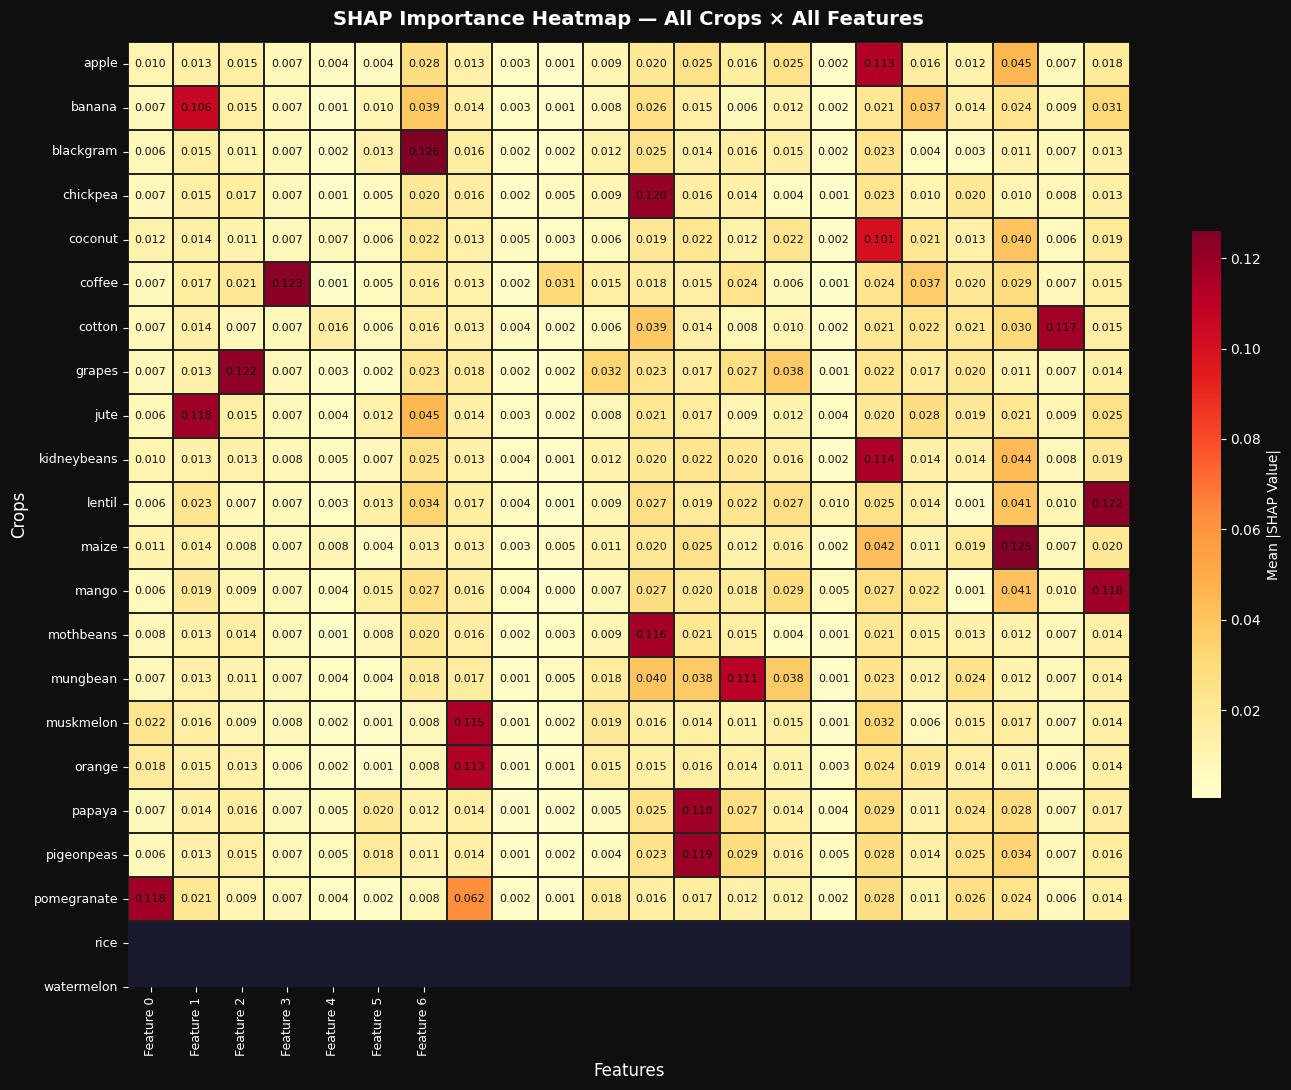

In [ ]:
# ── SHAP Plot 3: Heatmap across ALL classes ───────────────────────────────
# Shows which features matter most for EACH crop
mean_shap_per_class = np.array([np.abs(sv).mean(axis=0) for sv in shap_values])
# shape: (n_classes, n_features)

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor('#0f0f0f')

sns.heatmap(
    mean_shap_per_class,
    xticklabels=features,
    yticklabels=class_names,
    cmap='YlOrRd',
    linewidths=0.3, linecolor='#222',
    annot=True, fmt='.3f', annot_kws={'size': 8, 'color': '#111'},
    ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Mean |SHAP Value|'}
)

ax.set_title('SHAP Importance Heatmap — All Crops × All Features',
              fontsize=14, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Features',   fontsize=12, color='white')
ax.set_ylabel('Crops',      fontsize=12, color='white')
ax.tick_params(axis='both', colors='white', labelsize=9)
plt.tight_layout()
plt.show()

Plot 4: SHAP single-prediction explanation
  Sample #0: True=orange, Predicted=orange


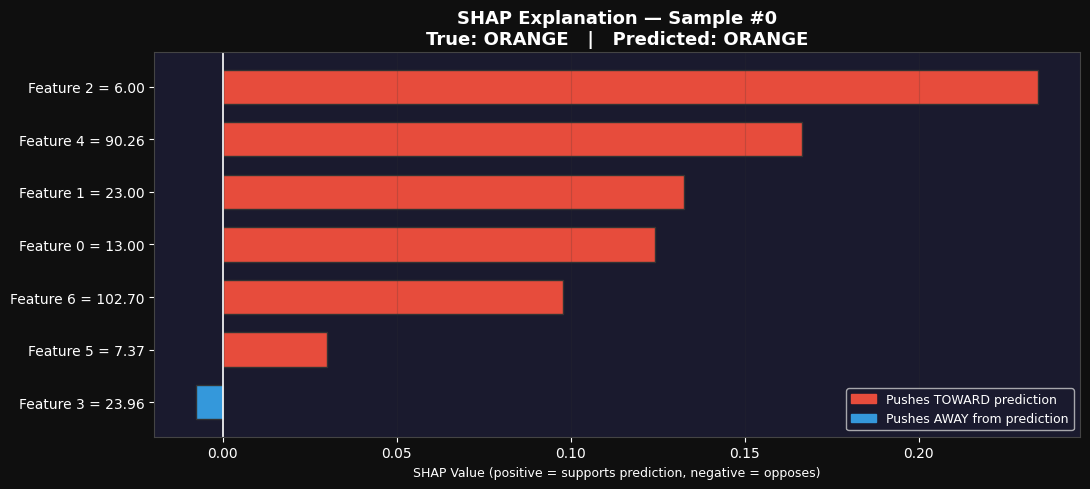

In [ ]:
print("Plot 4: SHAP single-prediction explanation")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sample_idx = 0

try:
    X_processed = X_test_scaled
except:
    X_processed = X_test

sample_input = X_processed[sample_idx:sample_idx+1]

true_label = class_names[y_test[sample_idx]]
pred_class_idx = rf_model.predict(sample_input)[0]
pred_label = class_names[pred_class_idx]

print(f"  Sample #{sample_idx}: True={true_label}, Predicted={pred_label}")

sv = shap_values

if isinstance(sv, list):
    sv_sample = sv[pred_class_idx][sample_idx]
else:
    sv_sample = sv[sample_idx, :, pred_class_idx]

n_features = len(sv_sample)
features = [f"Feature {i}" for i in range(n_features)]

sorted_sv_idx = np.argsort(np.abs(sv_sample))
sorted_sv_feats = [features[i] for i in sorted_sv_idx]
sorted_sv_vals = sv_sample[sorted_sv_idx]

try:
    raw_vals = scaler.inverse_transform(sample_input)[0]
except:
    raw_vals = sample_input[0]

labels = [f"{feat} = {raw_vals[i]:.2f}" for feat, i in zip(sorted_sv_feats, sorted_sv_idx)]
colors = ['#e74c3c' if v > 0 else '#3498db' for v in sorted_sv_vals]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

ax.barh(labels, sorted_sv_vals, color=colors, edgecolor='#333', height=0.65)
ax.axvline(0, color='white', linewidth=1.2)

ax.set_title(f'SHAP Explanation — Sample #{sample_idx}\nTrue: {true_label.upper()}   |   Predicted: {pred_label.upper()}',
             fontsize=13, fontweight='bold', color='white')

ax.set_xlabel('SHAP Value (positive = supports prediction, negative = opposes)', fontsize=9)
ax.grid(True, alpha=0.2, axis='x')

red_patch = mpatches.Patch(color='#e74c3c', label='Pushes TOWARD prediction')
blue_patch = mpatches.Patch(color='#3498db', label='Pushes AWAY from prediction')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)

plt.tight_layout()
plt.show()

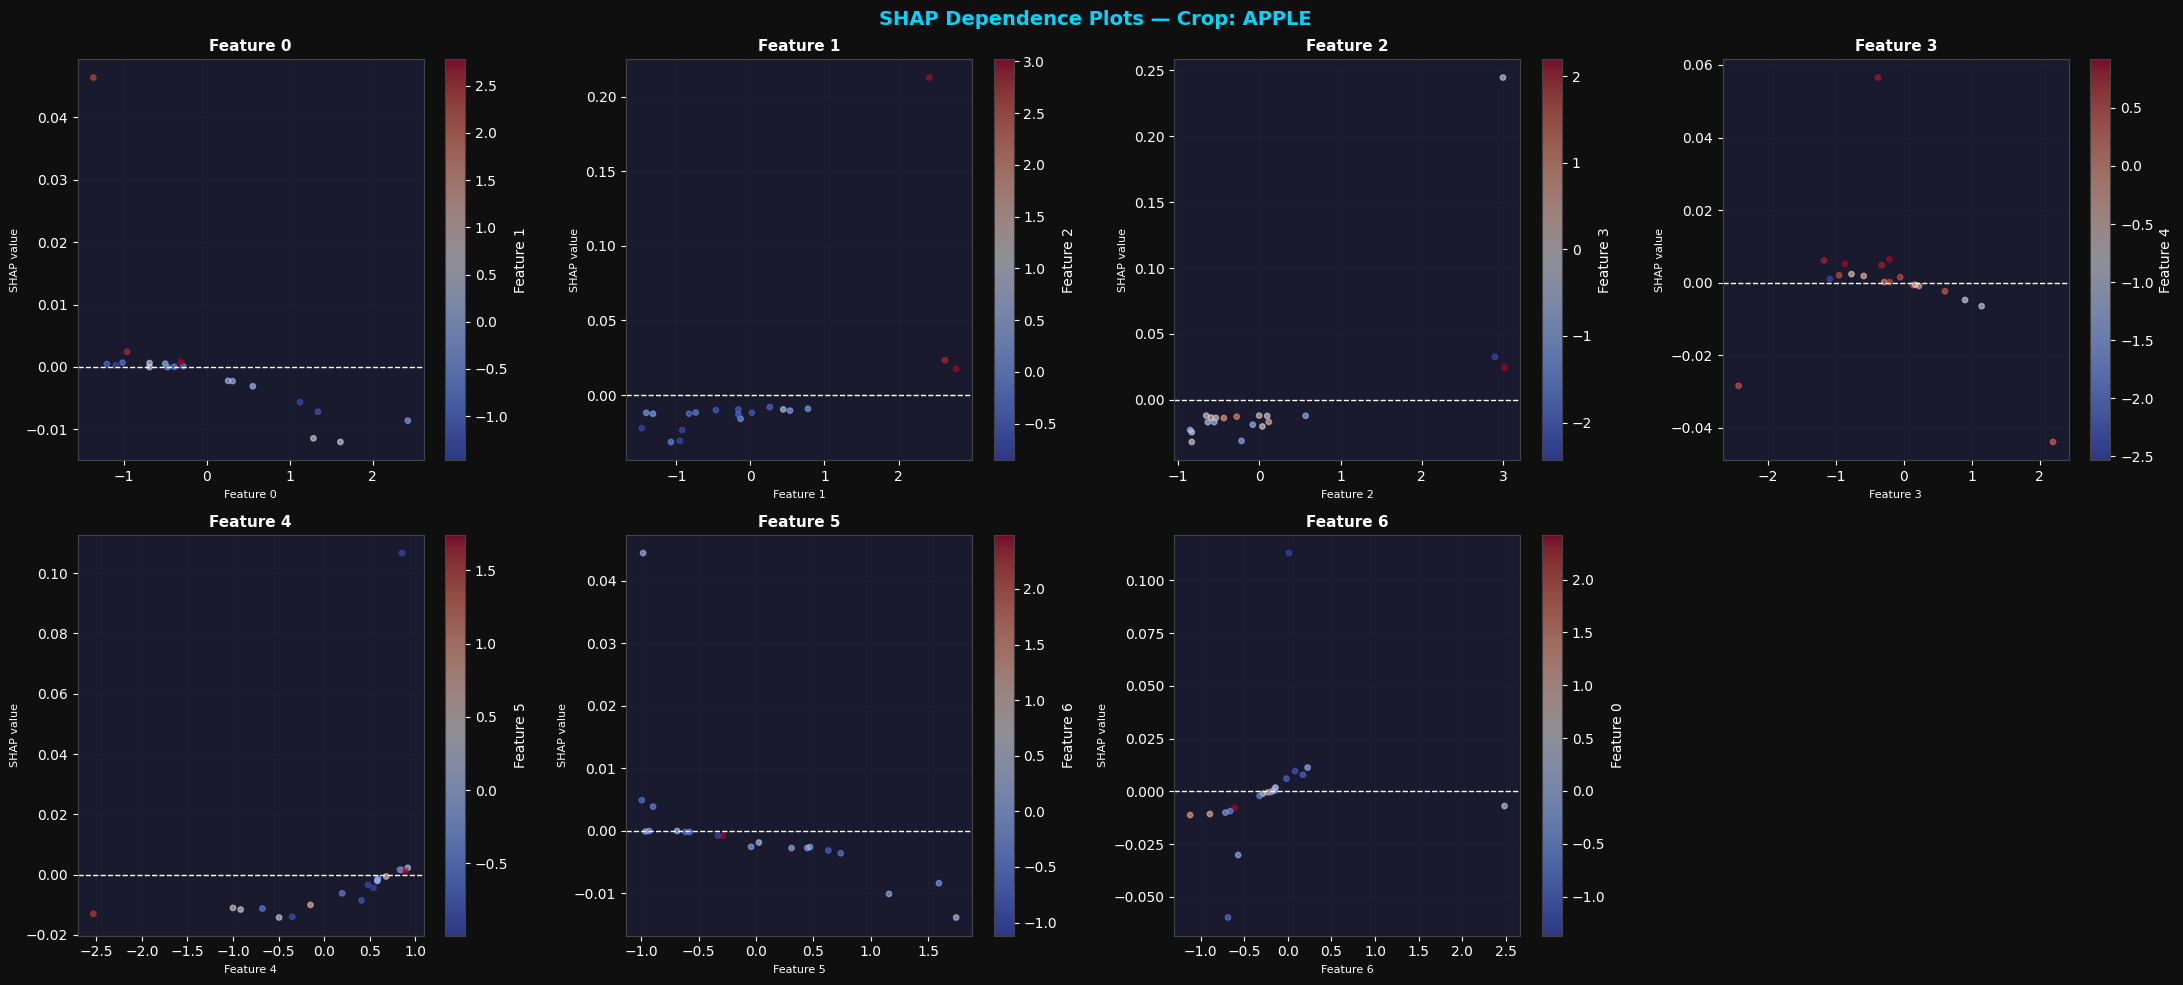

In [ ]:
best_class_idx = 0

try:
    X_processed = X_test_scaled
except:
    X_processed = X_test

sv = shap_values

if isinstance(sv, list):
    shap_mat = sv[best_class_idx]
else:
    shap_mat = sv[:, :, best_class_idx]

n_samples, n_features = shap_mat.shape
X_used = X_processed[:n_samples, :n_features]

features = [f"Feature {i}" for i in range(n_features)]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

for i in range(min(n_features, len(axes))):
    feat_idx = i
    feat_vals = X_used[:, feat_idx]
    shap_vals = shap_mat[:, feat_idx]

    color_feat_idx = (feat_idx + 1) % n_features
    color_vals = X_used[:, color_feat_idx]

    sc = axes[i].scatter(feat_vals, shap_vals, c=color_vals,
                         cmap='coolwarm', alpha=0.6, s=15)

    axes[i].axhline(0, color='white', linewidth=1, linestyle='--')
    axes[i].set_title(features[feat_idx], fontsize=11, fontweight='bold', color='white')
    axes[i].set_xlabel(f'{features[feat_idx]}', fontsize=8)
    axes[i].set_ylabel('SHAP value', fontsize=8)
    axes[i].grid(True, alpha=0.15)

    plt.colorbar(sc, ax=axes[i], label=features[color_feat_idx])

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'SHAP Dependence Plots — Crop: {class_names[best_class_idx].upper()}',
             fontsize=14, fontweight='bold', color='#00d4ff')

plt.tight_layout()
plt.show()

Uncertainty Stats across 440 test samples:
  Mean Uncertainty  : 0.0182
  Mean Confidence   : 81.8%
  High Confidence (>90%) : 184 samples
  Low  Confidence (<70%) : 89 samples


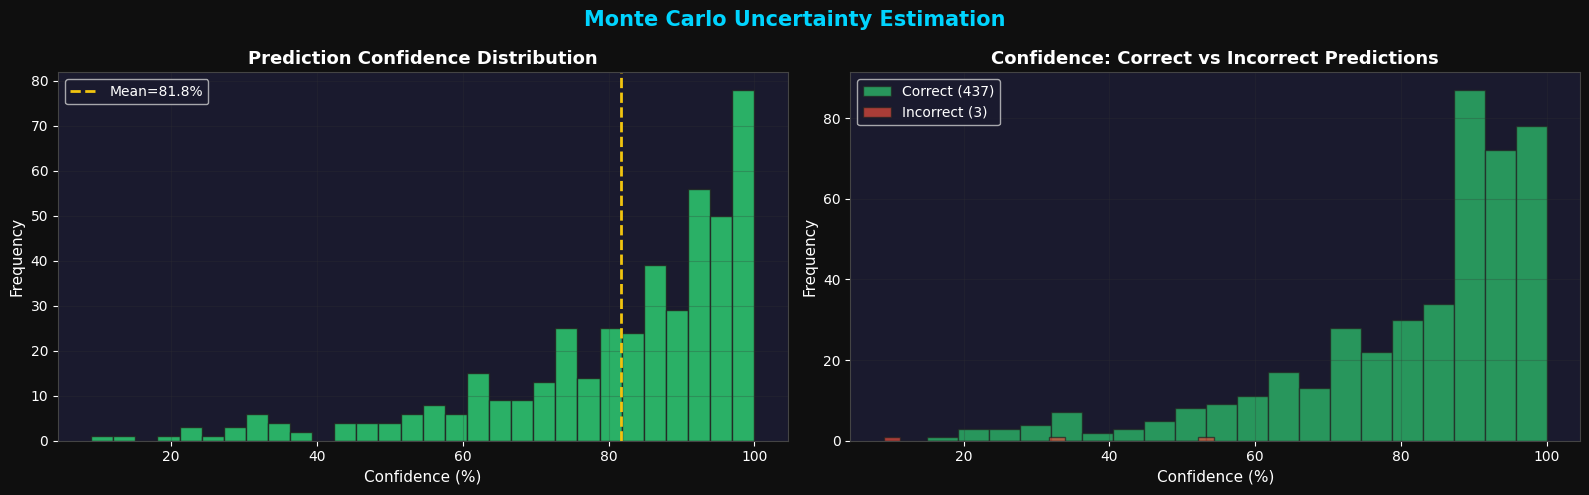

In [ ]:
# ── Monte Carlo Uncertainty via RF Tree Disagreement ─────────────────────
# Each tree in Random Forest = one "random expert"
# We measure how much they DISAGREE on a prediction
# High disagreement = uncertain prediction

def monte_carlo_uncertainty(rf, X_input):
    tree_preds = np.array([tree.predict_proba(X_input)[0]
                            for tree in rf.estimators_])
    mean_proba   = tree_preds.mean(axis=0)
    std_proba    = tree_preds.std(axis=0)
    uncertainty  = float(std_proba.mean())
    confidence   = max(0, min(100, (1 - uncertainty * 10) * 100))
    return mean_proba, uncertainty, confidence

# ── Run on all test samples ────────────────────────────────────────────────
rf = trained_models['Random Forest']
all_uncertainty = []
all_confidence  = []

for i in range(len(X_test)):
    _, unc, conf = monte_carlo_uncertainty(rf, X_test[i:i+1])
    all_uncertainty.append(unc)
    all_confidence.append(conf)

all_uncertainty = np.array(all_uncertainty)
all_confidence  = np.array(all_confidence)

print(f"Uncertainty Stats across {len(X_test)} test samples:")
print(f"  Mean Uncertainty  : {all_uncertainty.mean():.4f}")
print(f"  Mean Confidence   : {all_confidence.mean():.1f}%")
print(f"  High Confidence (>90%) : {(all_confidence > 90).sum()} samples")
print(f"  Low  Confidence (<70%) : {(all_confidence < 70).sum()} samples")

# ── Visualize ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f0f')

# Confidence distribution
axes[0].hist(all_confidence, bins=30, color='#2ecc71', alpha=0.85, edgecolor='#222')
axes[0].axvline(all_confidence.mean(), color='#f1c40f', linewidth=2,
                linestyle='--', label=f'Mean={all_confidence.mean():.1f}%')
axes[0].set_title('Prediction Confidence Distribution', fontsize=13,
                   fontweight='bold', color='white')
axes[0].set_xlabel('Confidence (%)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.25)

# Confidence vs correctness
correct_conf   = all_confidence[rf.predict(X_test) == y_test]
incorrect_conf = all_confidence[rf.predict(X_test) != y_test]
axes[1].hist(correct_conf,   bins=20, color='#2ecc71', alpha=0.7,
             label=f'Correct ({len(correct_conf)})',   edgecolor='#222')
axes[1].hist(incorrect_conf, bins=20, color='#e74c3c', alpha=0.7,
             label=f'Incorrect ({len(incorrect_conf)})', edgecolor='#222')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions',
                   fontsize=13, fontweight='bold', color='white')
axes[1].set_xlabel('Confidence (%)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.25)

plt.suptitle('Monte Carlo Uncertainty Estimation', fontsize=15,
             fontweight='bold', color='#00d4ff')
plt.tight_layout()
plt.show()

In [ ]:
# ── Prediction Function ────────────────────────────────────────────────────
def predict_crop(N, P, K, temperature, humidity, ph, rainfall,
                 model_name='Stacking Ensemble'):
    """
    Predict the best crop for given soil and weather conditions.

    Parameters:
        N           : Nitrogen (mg/kg)
        P           : Phosphorus (mg/kg)
        K           : Potassium (mg/kg)
        temperature : Temperature (°C)
        humidity    : Humidity (%)
        ph          : pH value (0-14)
        rainfall    : Rainfall (mm)
        model_name  : Which model to use (default: Stacking Ensemble)
    """
    raw_input   = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    scaled_input = scaler.transform(raw_input)

    # Select model
    if model_name == 'Stacking Ensemble':
        model = stacked_clf
    else:
        model = trained_models[model_name]

    pred_idx  = model.predict(scaled_input)[0]
    pred_crop = le.inverse_transform([pred_idx])[0]
    pred_prob = model.predict_proba(scaled_input)[0]

    # Top 3 predictions
    top3_idx   = np.argsort(pred_prob)[::-1][:3]
    top3_crops = le.inverse_transform(top3_idx)
    top3_probs = pred_prob[top3_idx] * 100

    # Monte Carlo Uncertainty
    _, unc, conf = monte_carlo_uncertainty(
        trained_models['Random Forest'], scaled_input)

    # ── Print Result ──────────────────────────────────────────────────────
    print("=" * 55)
    print("  CROP RECOMMENDATION RESULT")
    print("=" * 55)
    print(f"  Input Conditions:")
    print(f"    Nitrogen (N)    : {N}")
    print(f"    Phosphorus (P)  : {P}")
    print(f"    Potassium  (K)  : {K}")
    print(f"    Temperature     : {temperature} °C")
    print(f"    Humidity        : {humidity} %")
    print(f"    pH              : {ph}")
    print(f"    Rainfall        : {rainfall} mm")
    print()
    print(f"  🌾 RECOMMENDED CROP : {pred_crop.upper()}")
    print(f"  Model Used         : {model_name}")
    print(f"  Confidence         : {top3_probs[0]:.1f}%")
    print(f"  Uncertainty Score  : {unc:.4f}")
    print()
    print("  Top 3 Candidates:")
    for crop, prob in zip(top3_crops, top3_probs):
        bar = "█" * int(prob / 5)
        print(f"    {crop:<15} {prob:5.1f}%  {bar}")
    print("=" * 55)

    return pred_crop, top3_crops, top3_probs


# ── Example Prediction ──────────────────────────────────────────────────────
predict_crop(
    N=90, P=42, K=43,
    temperature=20.8, humidity=82.0,
    ph=6.5, rainfall=202.9
)

  CROP RECOMMENDATION RESULT
  Input Conditions:
    Nitrogen (N)    : 90
    Phosphorus (P)  : 42
    Potassium  (K)  : 43
    Temperature     : 20.8 °C
    Humidity        : 82.0 %
    pH              : 6.5
    Rainfall        : 202.9 mm

  🌾 RECOMMENDED CROP : RICE
  Model Used         : Stacking Ensemble
  Confidence         : 98.2%
  Uncertainty Score  : 0.0198

  Top 3 Candidates:
    rice             98.2%  ███████████████████
    jute              0.5%  
    pigeonpeas        0.1%  


('rice',
 array(['rice', 'jute', 'pigeonpeas'], dtype=object),
 array([9.81641920e+01, 5.41200511e-01, 7.55329000e-02]))

In [ ]:
# ── More Examples ──────────────────────────────────────────────────────
examples = [
    dict(N=0,   P=45, K=45, temperature=27, humidity=90, ph=7.0, rainfall=200,  label='mango?'),
    dict(N=100, P=18, K=20, temperature=25, humidity=70, ph=6.0, rainfall=100,  label='maize?'),
    dict(N=20,  P=30, K=30, temperature=24, humidity=85, ph=5.8, rainfall=250,  label='coffee?'),
    dict(N=80,  P=40, K=40, temperature=38, humidity=65, ph=6.8, rainfall=60,   label='cotton?'),
]

for ex in examples:
    label = ex.pop('label')
    print(f"\n>>> Expecting: {label}")
    predict_crop(**ex, model_name='Random Forest')


>>> Expecting: mango?
  CROP RECOMMENDATION RESULT
  Input Conditions:
    Nitrogen (N)    : 0
    Phosphorus (P)  : 45
    Potassium  (K)  : 45
    Temperature     : 27 °C
    Humidity        : 90 %
    pH              : 7.0
    Rainfall        : 200 mm

  🌾 RECOMMENDED CROP : PAPAYA
  Model Used         : Random Forest
  Confidence         : 74.0%
  Uncertainty Score  : 0.0827

  Top 3 Candidates:
    papaya           74.0%  ██████████████
    pomegranate       7.0%  █
    jute              6.7%  █

>>> Expecting: maize?
  CROP RECOMMENDATION RESULT
  Input Conditions:
    Nitrogen (N)    : 100
    Phosphorus (P)  : 18
    Potassium  (K)  : 20
    Temperature     : 25 °C
    Humidity        : 70 %
    pH              : 6.0
    Rainfall        : 100 mm

  🌾 RECOMMENDED CROP : MAIZE
  Model Used         : Random Forest
  Confidence         : 59.0%
  Uncertainty Score  : 0.0839

  Top 3 Candidates:
    maize            59.0%  ███████████
    coffee           21.3%  ████
    cotton     